# 06 · Is spend *causing* sales? — causal MMM (pymc-marketing)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Brand search converts like crazy — should we pour budget into it? Be careful:
brand search mostly **catches** demand that upper-funnel channels (TV) and seasonality already created, so
crediting it for those conversions and shifting budget its way would be a mistake.

### The concepts

- **MMM (Marketing Mix Model)** — a regression of sales on each channel's spend over time (usually weekly),
  used to attribute sales to channels and set budgets. It's the "top-down" alternative to click-tracking.
- **Adstock (carry-over)** — advertising doesn't only work the week it runs; its effect *decays over
  subsequent weeks*. Adstock transforms raw spend into an "effective" exposure that carries over.
- **Saturation (diminishing returns)** — the 10th €1,000 into a channel buys less lift than the 1st. A
  saturation curve bends over as spend rises; its *slope* is the **marginal** return that should drive the
  next euro of budget.
- **Last-click attribution** — crediting the conversion to the final touch (often brand search). It
  systematically **over-credits** demand-capture channels, which is the error a causal MMM aims to fix.
- **Incremental vs mediated** — the *incremental* contribution of a channel is what it *caused*; a channel
  can show a big correlation with sales while causing very little (it was downstream of the real driver).

### The arc of this notebook — a cautionary tale with a resolution

A plain MMM regresses sales on all channels and is fooled by a **confounder** like seasonality (it lifts
sales *and* drives brand-search spend). The textbook fix is a **causal MMM**: hand it a **DAG** and let the
backdoor logic (nb 05) control for the confounder. This notebook shows that fix is **necessary but not
sufficient**, in three acts — preceded by a fourth thing worth knowing:

0. **Step 0 · the classical read.** Before any Bayesian machinery we fit the MMM the way most agencies
   actually do: grid-search the adstock decay and the saturation half-point to minimise squared error,
   then run OLS on the transformed spend with honest (HAC) standard errors. It produces a clean answer —
   and we show that the data barely constrain those transform constants at all, so the neat interval it
   reports is **conditional on a choice made in a spreadsheet**. That precise failure is the reason the
   rest of this notebook exists; §5x returns to grade the Bayesian answer against it, honestly.
1. **The confounding correction works — in a linear model.** A naive OLS attribution that omits seasonality
   massively over-credits brand_search; adding seasonality as a control collapses that credit toward the
   small truth. That's the cleanest way to *see* the confounding, and it's robust.
2. **The out-of-the-box causal MMM still inverts the ranking.** Fit with library-default priors, the MMM's
   *flexible saturation curve* for brand_search **re-absorbs** the seasonal demand the linear control was
   meant to remove — so it credits brand_search *more* than TV, the opposite of the truth. A DAG plus a
   linear control does **not** de-confound a channel whose spend is collinear with the confounder.
3. **Experiment-calibrated priors recover it.** Feed in what a small **geo experiment** teaches — that
   brand_search's incremental effect is small — as an informative prior on its saturation, and the MMM
   ranks the channels correctly again. **This is why MMMs must be calibrated with experiments** (Anchor B,
   nb 07): observational data alone cannot pin the decomposition.

> **On real data.** Swap in your **own weekly spend-by-channel + sales** table plus known confounders
> (seasonality, price, distribution). Public example: the datasets shipped with Meta's *Robyn* or
> `pymc-marketing`'s own tutorials. Always pair an MMM with occasional geo experiments to anchor the levels.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from pymc_marketing.prior import Prior
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
DRAWS = dict(draws=250, tune=300, chains=2) if FAST else dict(draws=1200, tune=2000, chains=4)
# Even with the season->brand_search collinearity kept moderate in the DGP, the MMM's saturation
# geometry needs deeper trees + high target_accept + long tuning to converge cleanly (r-hat ~1.01).
NUTS = dict(target_accept=0.9) if FAST else dict(target_accept=0.99, max_treedepth=13)
SEED = 21
# Step-5 prior-sensitivity sweep refits: deliberately RANKING-GRADE (short chains, enough for
# stable posterior means and a stable ranking probability, not interval-grade diagnostics) so the
# sweep stays cheap in BOTH profiles — the FULL headline fits above are the only long chains here.
SWEEP_DRAWS = dict(draws=150, tune=200, chains=2) if FAST else dict(draws=250, tune=300, chains=2)

## 2 · Simulate a ground truth

Weekly sales from a faithful **adstock + Michaelis-Menten saturation** process. **TV** is a big
genuine driver. **seasonality** is a **confounder** — it lifts sales directly *and* drives
brand-search spend. **brand_search** has only a *small* real effect, but its spend rides the
seasonal wave (corr ≈ 0.78), so a naive attribution ignoring seasonality massively over-credits it.
Honest answer: TV highly incremental, brand_search only slightly.

**The data-generating model** — exactly what `dgp.mmm_weekly` implements (defaults & seed in
`src/cmp/dgp.py`). Weeks $t = 0,\dots,155$; seasonality $s_t = \sin(2\pi t/52)$:

$$
\begin{aligned}
x^{\text{tv}}_t &= \max\{1,\; 40 + 8\,s_t + \varepsilon^{\text{tv}}_t\},
  \quad \varepsilon^{\text{tv}}_t \sim \mathcal N(0, 8^{2});
  \qquad
x^{\text{bs}}_t = \max\{1,\; 25 + 11\,s_t + \varepsilon^{\text{bs}}_t\},
  \quad \varepsilon^{\text{bs}}_t \sim \mathcal N(0, 7^{2})\\[2pt]
a_t(x;\lambda) &= x_t + \lambda\, a_{t-1}(x;\lambda) \qquad\text{(geometric adstock / carry-over)}\\[2pt]
f(a;\alpha,\kappa) &= \frac{\alpha\, a}{\kappa + a} \qquad\text{(Michaelis–Menten saturation)}\\[2pt]
\text{sales}_t &= 100
  \;+\; \underbrace{f\big(a_t(x^{\text{tv}};\,0.4);\; 60,\, 50\big)}_{\text{TV: big, real}}
  \;+\; \underbrace{f\big(a_t(x^{\text{bs}};\,0.2);\; 8,\, 40\big)}_{\text{brand search: small, real}}
  \;+\; \underbrace{35\, s_t}_{\text{season} \to \text{sales}}
  \;+\; \varepsilon_t, \qquad \varepsilon_t \sim \mathcal N(0,\, 4^{2}).
\end{aligned}
$$

The confounding is the **two appearances of $s_t$**: it drives brand-search spend (the $11\,s_t$
term — people search the brand more in peak season; corr ≈ 0.78) *and* sales directly (the
$35\,s_t$ term). An MMM that omits seasonality hands much of that $35\,s_t$ to brand search. Note
the generator uses the MMM's own functional form (adstock → saturation), so the model is
well-specified — any remaining failure is about *identification*, not fit. **Identification** is whether the data can, even in principle, pin down the answer uniquely: a model can fit the sales series perfectly and still leave the *split* of credit between two channels undetermined — that gap between 'fits' and 'is identified' is the whole subject of this notebook.


In [2]:
df, true_contrib = dgp.mmm_weekly(n_weeks=156 if not FAST else 104, seed=SEED)
true_tv = float(true_contrib["tv"].sum()); true_bs = float(true_contrib["brand_search"].sum())
print(f"TRUE incremental sales — TV {true_tv:,.0f}   brand_search {true_bs:,.0f} (small)")
df.head()

TRUE incremental sales — TV 5,263   brand_search 518 (small)


,date_week,tv,brand_search,seasonality,sales
0,2023-01-02,42.870187,35.579322,0.000000,134.900978
1,2023-01-09,53.049712,17.732754,0.120537,137.863335
2,2023-01-16,27.623875,23.486826,0.239316,142.263680
3,2023-01-23,56.329747,34.885672,0.354605,159.788875
4,2023-01-30,43.339248,33.736743,0.464723,152.485792


### First — look at the data: the confounding, made visible

Two pictures to hold in your head for the rest of the notebook, drawn **before any model sees the
data**:

1. **Spend rides the seasonal wave.** brand_search's spend is *built* from the same seasonal index
   that lifts sales, so it tracks the dashed wave far more tightly than TV does (both correlations
   are printed in the legend). Whatever the season does to sales will look, to a model that ignores
   the season, like brand_search doing it.
2. **Most of what brand_search appears to move is the season.** The right panel plots the *planted*
   weekly components of sales: TV's contribution is large, the ±35 seasonal swing is larger still —
   and brand_search's true contribution is the near-flat line hugging the bottom. An attribution
   method must hand the wave back to the season; everything that follows is about whether it does.

corr(spend, seasonality): brand_search 0.78 vs tv 0.63 — the confounder is entangled
with brand_search; true weekly contributions: TV ≈ €34, brand_search ≈ €3, season swing ±€35.


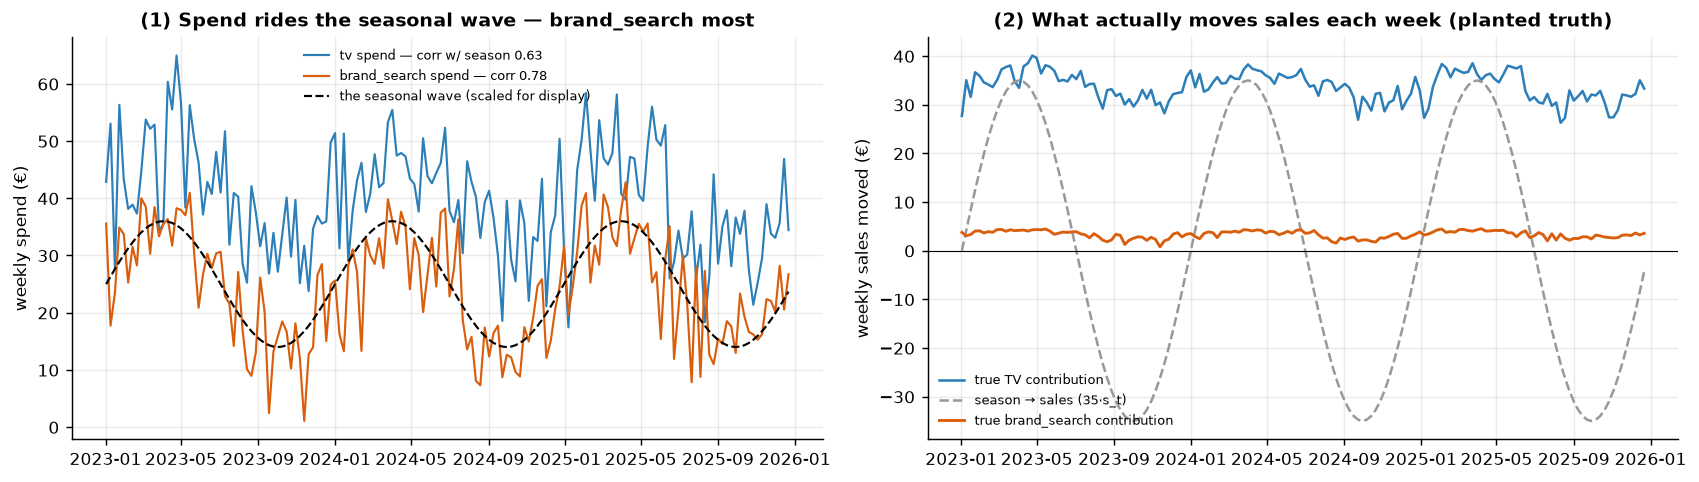

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13.2, 3.8))
c_tv = df["tv"].corr(df["seasonality"]); c_bs = df["brand_search"].corr(df["seasonality"])
ax[0].plot(df["date_week"], df["tv"], color=plots.BLUE, lw=1.2, label=f"tv spend — corr w/ season {c_tv:.2f}")
ax[0].plot(df["date_week"], df["brand_search"], color=plots.ORANGE, lw=1.2,
           label=f"brand_search spend — corr {c_bs:.2f}")
ax[0].plot(df["date_week"], 25 + 11 * df["seasonality"], color="k", ls="--", lw=1.2,
           label="the seasonal wave (scaled for display)")
ax[0].set_ylabel("weekly spend (€)"); ax[0].legend(frameon=False, fontsize=7)
ax[0].set_title("(1) Spend rides the seasonal wave — brand_search most")
ax[1].plot(df["date_week"], true_contrib["tv"], color=plots.BLUE, lw=1.4, label="true TV contribution")
ax[1].plot(df["date_week"], 35 * df["seasonality"], color=plots.GREY, lw=1.4, ls="--",
           label="season → sales (35·s_t)")
ax[1].plot(df["date_week"], true_contrib["brand_search"], color=plots.ORANGE, lw=1.6,
           label="true brand_search contribution")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("weekly sales moved (€)"); ax[1].legend(frameon=False, fontsize=7)
ax[1].set_title("(2) What actually moves sales each week (planted truth)")
fig.tight_layout()
print(f"corr(spend, seasonality): brand_search {c_bs:.2f} vs tv {c_tv:.2f} — the confounder is entangled")
print(f"with brand_search; true weekly contributions: TV ≈ €{np.mean(true_contrib['tv']):,.0f}, "
      f"brand_search ≈ €{np.mean(true_contrib['brand_search']):,.0f}, season swing ±€35.")

### The two transforms, before we use them in anger

The MMM's channel response is built from the two primitives the generator above already used —
worth ten seconds of intuition each before a sampler spends minutes on them. **Adstock** answers
*"how long does an ad echo?"*: with geometric decay $\lambda$, a euro of spend still exerts
$\lambda^{\ell}$ of its initial push $\ell$ weeks later, so $\lambda = 0.2$ is a one-week echo
while $\lambda = 0.8$ still echoes seven weeks out. **Saturation** answers *"what is the next euro
worth?"*: the Michaelis–Menten curve $f(a) = \alpha a/(\kappa + a)$ climbs toward a **ceiling**
$\alpha$ — the most the channel could ever add per week — and passes half of it exactly at
$a = \kappa$, the **half-saturation** point. Keep the right panel in mind for Step 4b: the
experiment-calibrated prior acts on the *ceiling* $\alpha$, the parameter that says how much a
channel could possibly deliver — precisely the number a lift test measures.

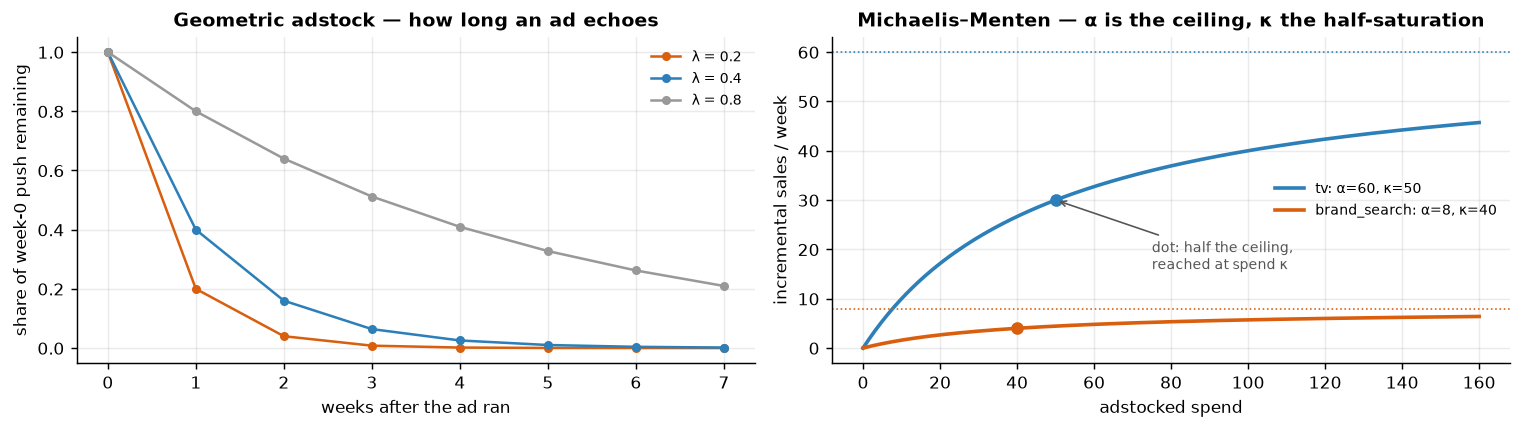

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.8, 3.4))
ell = np.arange(8)
for lam, col in [(0.2, plots.ORANGE), (0.4, plots.BLUE), (0.8, plots.GREY)]:
    ax[0].plot(ell, lam ** ell, "o-", ms=4, lw=1.4, color=col, label=f"λ = {lam}")
ax[0].set_xlabel("weeks after the ad ran"); ax[0].set_ylabel("share of week-0 push remaining")
ax[0].set_title("Geometric adstock — how long an ad echoes"); ax[0].legend(frameon=False, fontsize=8)
a_grid = np.linspace(0, 160, 200)
for (al, ka), col, lab in [((60, 50), plots.BLUE, "tv: α=60, κ=50"),
                           ((8, 40), plots.ORANGE, "brand_search: α=8, κ=40")]:
    ax[1].plot(a_grid, al * a_grid / (ka + a_grid), color=col, lw=2, label=lab)
    ax[1].axhline(al, color=col, ls=":", lw=0.9)
    ax[1].plot([ka], [al / 2], "o", color=col, ms=6)
ax[1].annotate("dot: half the ceiling,\nreached at spend κ", xy=(50, 30), xytext=(75, 16),
               fontsize=7.5, color="#555555", arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))
ax[1].set_xlabel("adstocked spend"); ax[1].set_ylabel("incremental sales / week")
ax[1].set_title("Michaelis–Menten — α is the ceiling, κ the half-saturation")
ax[1].legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()

## 3 · Identify — the marketing DAG picks what to control for

DAG: `seasonality → {sales, brand_search}`, `tv → sales`, `brand_search → sales`. The backdoor
criterion says **seasonality is a confounder → control for it**; omitting it is exactly the
last-click mistake that over-credits brand search. (This DAG has a confounder but no **mediator** — a
variable sitting *on* the causal path from spend to sales, which you would deliberately *not* control for;
nb 05 covers that distinction.) The **estimand** — the precise quantity we want to estimate — for channel
$c$ is its **incremental contribution** — sum over weeks of
$\mathbb E[\text{sales}\mid do(\text{spend}_c=\text{observed})]-\mathbb E[\text{sales}\mid do(\text{spend}_c=0)]$,
holding the other channels at their observed spend (how much of sales would vanish if we switched channel $c$
off). Here $do(\cdot)$ denotes an **intervention** — setting spend by decree rather than merely observing it
(nb 05). **ROAS** (return on ad spend) = incremental contribution ÷ spend, each with a posterior — note this
is *revenue*, not profit, so at 1× you break even only on a 100% margin (we return to margins in Step 6).
Identification comes from the backdoor set $\{\text{seasonality}\}$; we hand the DAG to the MMM via `dag`,
`treatment_nodes`, `outcome_node`.

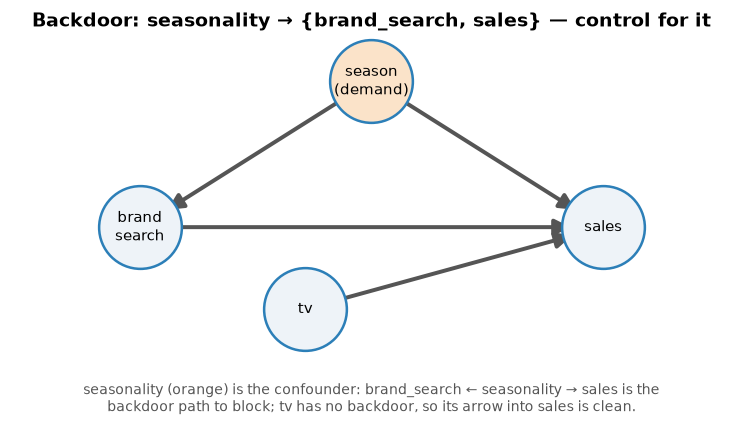

In [5]:
fig, ax = plt.subplots(figsize=(5.8, 3.4))
pos = {"season\n(demand)": (0.5, 1.0), "brand\nsearch": (0.08, 0.5), "tv": (0.38, 0.22), "sales": (0.92, 0.5)}
edges = [("season\n(demand)", "brand\nsearch"), ("season\n(demand)", "sales"),
         ("brand\nsearch", "sales"), ("tv", "sales")]
plots.draw_dag(ax, pos, edges, node_colors={"season\n(demand)": "#fbe3c9"},
               title="Backdoor: seasonality → {brand_search, sales} — control for it")
ax.text(0.5, -0.13, "seasonality (orange) is the confounder: brand_search ← seasonality → sales is the\n"
                    "backdoor path to block; tv has no backdoor, so its arrow into sales is clean.",
        ha="center", fontsize=7.5, color="#555555")
fig.tight_layout()

In [6]:
dag = '''digraph { seasonality -> sales; seasonality -> brand_search; tv -> sales; brand_search -> sales; }'''
X = df[["date_week","tv","brand_search","seasonality"]]; y = df["sales"]

def make_mmm(model_config=None):
    return MMM(date_column="date_week", channel_columns=["tv","brand_search"], control_columns=["seasonality"],
               adstock=GeometricAdstock(l_max=8), saturation=MichaelisMentenSaturation(),
               dag=dag, treatment_nodes=["tv","brand_search"], outcome_node="sales",
               model_config=model_config)

mmm_default = make_mmm()
print("Backdoor adjustment set the causal layer will use:",
      mmm_default.causal_graphical_model.adjustment_set if hasattr(mmm_default,"causal_graphical_model") else "n/a")

Backdoor adjustment set the causal layer will use: ['seasonality']


## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, what does a competent analyst *without* it do here? Exactly what most
agencies do, and it is worth doing well, because its **specific failure** is what motivates
everything below. The estimand is unchanged from §3 — each channel's incremental contribution, and
its ROAS — and so is the identification argument: the backdoor set is $\{\text{seasonality}\}$, so
seasonality enters the regression as a control. The causal work lives in that DAG, not in the
estimator. What changes is only how we *estimate*.

**The obstruction.** Write the MMM as a regression. Adstock the spend, saturate it, add the control:

$$
a_{c,t}(\lambda_c) \;=\; x_{c,t} + \lambda_c\, a_{c,t-1}(\lambda_c),
\qquad
g_{c,t}(\lambda_c, \kappa_c) \;=\; \frac{a_{c,t}(\lambda_c)}{\kappa_c + a_{c,t}(\lambda_c)},
\qquad
\text{sales}_t \;=\; \beta_0 \;+\; \sum_c \alpha_c\, g_{c,t}(\lambda_c,\kappa_c) \;+\; \gamma\, s_t \;+\; u_t .
$$

Note what the algebra just did: dividing the Michaelis–Menten curve
$f_c(a) = \alpha_c a/(\kappa_c + a)$ by its ceiling leaves the **unit-ceiling basis**
$g_{c,t} \in (0,1)$, and the ceiling $\alpha_c$ comes back out as the plain OLS **coefficient** on
that basis. So *given* the transform parameters $(\lambda_c, \kappa_c)$ the model is linear and OLS
estimates $\alpha_c$, $\gamma$ and $\beta_0$ in closed form. The decay $\lambda_c$ and the
half-saturation $\kappa_c$, however, enter **non-linearly** — and there is no closed form for them,
no OLS interval for them, and (as we are about to see) barely any information about them in a
weekly series whose spend rides the seasonal wave.

**The classical move: profile them out.** Concentrated (profile) least squares — grid-search the
four transform parameters, and at each candidate solve the linear part exactly:

$$
(\hat\lambda, \hat\kappa) \;=\; \arg\min_{\lambda,\, \kappa}\;
\underbrace{\min_{\beta_0,\, \alpha,\, \gamma}\;
\sum_{t}\Big(\text{sales}_t - \beta_0 - \sum_c \alpha_c\, g_{c,t}(\lambda_c,\kappa_c) - \gamma\, s_t\Big)^{2}}_{\text{SSE}(\lambda,\kappa)\ \text{— the OLS fit at that transform}} ,
$$

then report OLS at $(\hat\lambda, \hat\kappa)$ **as if those were known**. That last clause is the
whole story of this section. It is not a strawman: it is what a careful agency does — and what a
careless one does by simply *asserting* "λ = 0.5, κ = half of average spend, everyone uses those".
Either way the transform is **fixed by fiat**, and the reported interval is conditional on it.

**The estimator and its covariance, named.** OLS on the transformed regressors, with **Newey–West
HAC** standard errors. Weekly sales are serially correlated — adstock alone guarantees it (this
week's sales inherit last week's exposure), and whatever seasonal structure the single $s_t$ control
fails to absorb persists across weeks — so the iid variance formula is simply not the right one
here, and an interval built on the wrong standard error is a confident lie. Lag truncation follows
the usual rule of thumb, $\lfloor 4 (n/100)^{2/9} \rfloor$ ≈ 4 weeks. The cell prints the residual
autocorrelation that motivates the choice *and* the factor by which HAC moved each standard error —
and note that "correct" does not automatically mean "wider": HAC re-weights, and where the seasonal
control has already absorbed most of the persistence it can come out **tighter** than iid. The point
is never that HAC inflates; it is that the covariance was *checked* rather than defaulted.

Contribution and ROAS then follow from the fitted ceiling by simple arithmetic — the CI carries
over by the same scaling, because both are **linear** in $\hat\alpha_c$:

$$
\widehat{\text{contrib}}_c \;=\; \hat\alpha_c \sum_t g_{c,t}(\hat\lambda_c, \hat\kappa_c),
\qquad
\widehat{\text{ROAS}}_c \;=\; \frac{\widehat{\text{contrib}}_c}{\sum_t x_{c,t}} .
$$


In [7]:
from cmp import classical as cl
from scipy import stats as _st

CH = ["tv", "brand_search"]
sales_v = df["sales"].values.astype(float); n_t = len(df)
spend_tot = {c: float(df[c].sum()) for c in CH}
true_contrib_tot = {"tv": true_tv, "brand_search": true_bs}

def _adstock(x, lam):                       # geometric carry-over, the DGP's own recursion
    out = np.empty(len(x)); out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + lam * out[i - 1]
    return out

def _sat_basis(c, lam, kap):                # g = a/(kappa+a): the MM curve with its ceiling divided out
    a = _adstock(df[c].values.astype(float), lam)
    return a / (kap + a)

# The searched grid. lambda in [0, 0.8] (a decay past 0.8 means an ad still echoing two months out).
# kappa as a multiple of the channel's OWN mean weekly spend: 0.2x (violently saturated) to 5x
# (essentially linear over the observed spend range) — the band a practitioner would call plausible.
LAM_GRID = np.round(np.arange(0.0, 0.81, 0.1 if FAST else 0.05), 2)
KAP_MULT = np.geomspace(0.2, 5.0, 6 if FAST else 12)
KAP_GRID = {c: KAP_MULT * float(df[c].mean()) for c in CH}
ADS = {c: {l: _adstock(df[c].values.astype(float), l) for l in LAM_GRID} for c in CH}
S_v, ONE = df["seasonality"].values, np.ones(n_t)
TSS = float(((sales_v - sales_v.mean()) ** 2).sum())

rows = []                                   # the profile: an exact OLS at every transform candidate
for lt in LAM_GRID:
    for kt in KAP_GRID["tv"]:
        g_tv = ADS["tv"][lt] / (kt + ADS["tv"][lt])
        for lb in LAM_GRID:
            for kb in KAP_GRID["brand_search"]:
                g_bs = ADS["brand_search"][lb] / (kb + ADS["brand_search"][lb])
                B = np.column_stack([ONE, g_tv, g_bs, S_v])
                b, *_ = np.linalg.lstsq(B, sales_v, rcond=None)
                r = sales_v - B @ b; sse = float(r @ r)
                rows.append((sse, 1 - sse / TSS, lt, kt, lb, kb,
                             float(b[1] * g_tv.sum()), float(b[2] * g_bs.sum()), float(b[0])))
GRID = pd.DataFrame(rows, columns=["sse", "r2", "lam_tv", "kap_tv", "lam_bs", "kap_bs",
                                   "c_tv", "c_bs", "intercept"])
GRID["roas_tv"] = GRID.c_tv / spend_tot["tv"]
GRID["roas_bs"] = GRID.c_bs / spend_tot["brand_search"]
hat = GRID.loc[GRID.sse.idxmin()]
LAM_HAT = {"tv": float(hat.lam_tv), "brand_search": float(hat.lam_bs)}
KAP_HAT = {"tv": float(hat.kap_tv), "brand_search": float(hat.kap_bs)}

print(f"Profiled {len(GRID):,} (λ, κ) settings by OLS SSE; best R² = {hat.r2:.4f}.")
print("The winner — these four numbers are now FIXED BY FIAT, no interval attached:")
for c in CH:
    lo, hi = KAP_GRID[c][0], KAP_GRID[c][-1]
    print(f"  {c:12s} λ̂ = {LAM_HAT[c]:.2f}   κ̂ = {KAP_HAT[c]:6.1f}  "
          f"(= {KAP_HAT[c] / float(df[c].mean()):.1f}× mean weekly spend)")
    if KAP_HAT[c] <= lo * 1.001 or KAP_HAT[c] >= hi * 0.999:
        print("               ^ κ̂ sits AT THE EDGE of the band: the SSE never")
        print("                 turned around — no interior optimum exists.")
print("  planted truth: tv λ=0.40, κ=50.0")
print("                 brand_search λ=0.20, κ=40.0")

# --- OLS at the profiled transform, HAC standard errors (weekly sales are autocorrelated) ---
dcl = df.rename(columns={"seasonality": "season"}).copy()
for c in CH:
    dcl[f"g_{c}"] = _sat_basis(c, LAM_HAT[c], KAP_HAT[c])
FORM = "sales ~ g_tv + g_brand_search + season"
MAXLAGS = int(4 * (n_t / 100) ** (2 / 9))          # Newey-West rule of thumb: ~4 weeks
CLS, tab = {}, []
for c in CH:
    r = cl.ols(dcl, FORM, target=f"g_{c}", cov="HAC", maxlags=MAXLAGS, name=f"{c} ceiling α")
    r_iid = cl.ols(dcl, FORM, target=f"g_{c}", cov="nonrobust")
    g_sum = float(dcl[f"g_{c}"].sum()); k_roas = g_sum / spend_tot[c]
    CLS[c] = {"alpha": r.estimate, "alpha_ci": r.ci,
              "contrib": r.estimate * g_sum, "contrib_ci": tuple(x * g_sum for x in r.ci),
              "roas": r.estimate * k_roas, "roas_ci": tuple(x * k_roas for x in r.ci),
              "se_infl": r.se / r_iid.se, "r": r}
    tab.append({"channel": c,
                "ceiling α̂ (€/wk)": f"{r.estimate:.1f} [{r.ci[0]:.1f}, {r.ci[1]:.1f}]",
                "contribution (€)": f"{CLS[c]['contrib']:,.0f} "
                                    f"[{CLS[c]['contrib_ci'][0]:,.0f}, {CLS[c]['contrib_ci'][1]:,.0f}]",
                "true (€)": f"{true_contrib_tot[c]:,.0f}",
                "ROAS (×)": f"{CLS[c]['roas']:.2f} [{CLS[c]['roas_ci'][0]:.2f}, {CLS[c]['roas_ci'][1]:.2f}]",
                "true (×)": f"{true_contrib_tot[c] / spend_tot[c]:.2f}"})
TAB = pd.DataFrame(tab)
print(f"\nOLS at the profiled transform · Newey-West HAC (maxlags={MAXLAGS}) · 90% CIs · n = {n_t}")
print(TAB[["channel", "ceiling α̂ (€/wk)", "contribution (€)", "true (€)"]].to_string(index=False))
print()
print(TAB[["channel", "ROAS (×)", "true (×)"]].to_string(index=False))
B_hat = np.column_stack([ONE] + [dcl[f"g_{c}"].values for c in CH] + [S_v])
b_hat, *_ = np.linalg.lstsq(B_hat, sales_v, rcond=None)
res_v = sales_v - B_hat @ b_hat
ac1 = float(np.corrcoef(res_v[:-1], res_v[1:])[0, 1])
print(f"\nWhy HAC: the residuals carry lag-1 autocorrelation {ac1:+.2f} — the iid")
print("variance formula does not apply here.")
print("HAC ÷ iid standard error: "
      + ", ".join(f"×{CLS[c]['se_infl']:.2f} ({c})" for c in CH) + ".")
# Report this PER CHANNEL: HAC re-weights, and the two channels can land on opposite
# sides of 1.0 — a blanket verdict would contradict the very numbers just printed.
tighter = [c for c in CH if CLS[c]["se_infl"] < 1.0]
wider = [c for c in CH if CLS[c]["se_infl"] >= 1.0]
_j = lambda xs: " and ".join(xs)
if tighter and wider:
    print(f"Split verdict: HAC came out TIGHTER than iid for {_j(tighter)} and WIDER")
    print(f"for {_j(wider)} — it RE-WEIGHTS, it does not only inflate.")
    print("The point is correctness, not conservatism.")
elif wider:
    print(f"Wider than iid for {_j(wider)}, as serial correlation usually implies —")
    print("but that is not guaranteed: HAC re-weights, it does not only inflate.")
    print("The point is correctness, not conservatism.")
else:
    print(f"It came out TIGHTER than iid for {_j(tighter)}: HAC re-weights, it does")
    print("not only inflate. The point is correctness, not conservatism.")

# --- grade it against the planted truth: the RANKING first, the levels second ---
rank_ok = CLS["tv"]["contrib"] > CLS["brand_search"]["contrib"]
print(f"\nGRADE vs the planted truth")
print(f"  ranking : classical says {'TV > brand_search' if rank_ok else 'brand_search > TV'}; "
      f"truth is TV first -> {'CORRECT' if rank_ok else 'INVERTED'}")
for c in CH:
    ratio = CLS[c]["contrib"] / true_contrib_tot[c]
    covered = CLS[c]["roas_ci"][0] <= true_contrib_tot[c] / spend_tot[c] <= CLS[c]["roas_ci"][1]
    print(f"  {c:12s}: contribution {ratio:.2f}× the truth · 90% ROAS CI holds it? "
          f"{'YES' if covered else 'NO'}")
if rank_ok:
    print("  -> the classical fit gets the RANKING right here — where §4a's")
    print("     default Bayesian MMM will not. Hold the applause: it bought that")
    print("     by FIXING the transform, an assumption it never defended. Run the")
    print("     same profiling on the shorter FAST series (CMP_FAST=1) and it")
    print("     inverts outright. The next cell measures how little the fit ever")
    print("     had to say about it.")
else:
    print("  -> the classical fit INVERTS the ranking: brand_search's saturation")
    print("     basis has re-absorbed the seasonal wave — the very failure the")
    print("     default Bayesian MMM commits in §4a, reached here with no priors")
    print("     and no sampler at all. The disease is the model's identification,")
    print("     not its machinery.")


Profiled 41,616 (λ, κ) settings by OLS SSE; best R² = 0.9804.
The winner — these four numbers are now FIXED BY FIAT, no interval attached:
  tv           λ̂ = 0.25   κ̂ =  197.9  (= 5.0× mean weekly spend)
               ^ κ̂ sits AT THE EDGE of the band: the SSE never
                 turned around — no interior optimum exists.
  brand_search λ̂ = 0.00   κ̂ =   11.6  (= 0.5× mean weekly spend)
  planted truth: tv λ=0.40, κ=50.0
                 brand_search λ=0.20, κ=40.0

OLS at the profiled transform · Newey-West HAC (maxlags=4) · 90% CIs · n = 156
     channel ceiling α̂ (€/wk)     contribution (€) true (€)
          tv 77.6 [57.6, 97.6] 2,526 [1,875, 3,178]    5,263
brand_search  5.2 [-1.9, 12.4]    528 [-194, 1,249]      518

     channel           ROAS (×) true (×)
          tv  0.41 [0.30, 0.51]     0.85
brand_search 0.14 [-0.05, 0.33]     0.14

Why HAC: the residuals carry lag-1 autocorrelation +0.18 — the iid
variance formula does not apply here.
HAC ÷ iid standard error: ×0.

**What we just got, and what it cost.** The table prints a complete, professional-looking answer:
a ceiling per channel, a contribution, a ROAS, each with a 90% interval computed off standard errors
that were *corrected for the serial correlation of weekly sales*. Grade it honestly against the
planted truth — the printed lines do, on the ranking and on the levels, and the read-out after the
next cell says plainly what they show.

But look again at the four numbers above the table. $\hat\lambda$ and $\hat\kappa$ came out of a
grid search, and they carry **no interval at all**. The regression that produced those neat CIs was
handed them as if they were *known constants*. So the honest question is not "is the point estimate
good?" but:

> **How much would the answer move if I had fixed the transform somewhere else — somewhere the data
> cannot rule out?**

That is a question the classical fit is structurally unable to answer, because it *conditioned on*
the answer. So we ask it from the outside, two ways: (1) re-fit across a grid of $(\lambda, \kappa)$
values a practitioner could defend a priori — the "everyone uses 0.5" spreadsheet choice — and (2)
compute, properly, the set of transform values the data genuinely **cannot distinguish**: the profile
(concentrated) likelihood region, using the standard Gaussian result that
$n \log\!\big(\mathrm{SSE}(\lambda,\kappa)/\mathrm{SSE}(\hat\lambda,\hat\kappa)\big)$ is
asymptotically $\chi^2_4$ under the null that $(\lambda,\kappa)$ is the truth — the very region
whose existence the "fix it and forget it" workflow denies.

The 90% profile region for (λ, κ) holds 25,340 of the 41,616 searched
settings — 61% of the grid. Inside it:
  λ_tv spans [0.00, 0.55] · λ_bs [0.00, 0.80]  (band: [0, 0.8])
  κ_tv spans [8, 198] · κ_bs spans [5, 121]  €/week
  -> the decay and the half-saturation point are, in practice, NOT IDENTIFIED.

What that costs the answer:
  TV ROAS across the region : [0.30, 3.44]  (width 3.14)
  the REPORTED 90% CI       : [0.30, 0.51]  (width 0.21) — 15× narrower
  true TV ROAS 0.85× lies OUTSIDE the reported CI, and inside
  the transform envelope.
  brand_search ROAS across the region: [-2.61, 1.30]  (true 0.14×)
  ranking TV > brand_search holds in 98% of the region.
  (1,374 settings in the region imply a NEGATIVE brand_search
   contribution — off the bottom of the right panel. The fit cannot
   rule those out either.)

"We use industry-standard values" — same data, the transform simply ASSERTED:
 λ (both)  κ (× mean spend)     R²  TV ROAS  bs ROAS  ranking
      0.2               0.5 0

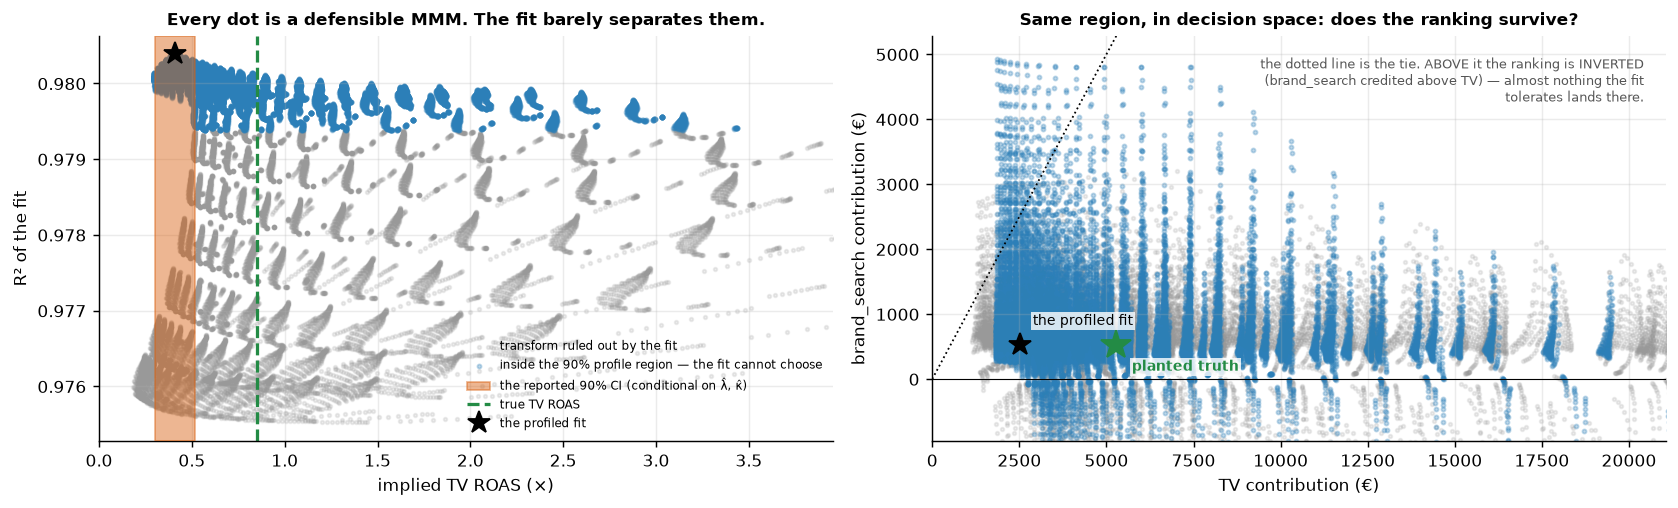

In [8]:
# --- (1) the profile-likelihood region for (λ, κ): what the fit genuinely CANNOT rule out ---
CRIT = float(_st.chi2.ppf(0.90, 4))                     # 4 transform parameters
REG = GRID[GRID.sse <= GRID.sse.min() * np.exp(CRIT / n_t)].copy()   # 90% profile region
OUT = GRID[GRID.sse > GRID.sse.min() * np.exp(CRIT / n_t)]
reg_rank_ok = float((REG.c_tv > REG.c_bs).mean())
ci_lo, ci_hi = CLS["tv"]["roas_ci"]; ci_w = ci_hi - ci_lo
env_lo, env_hi = float(REG.roas_tv.min()), float(REG.roas_tv.max()); env_w = env_hi - env_lo
true_roas = {c: true_contrib_tot[c] / spend_tot[c] for c in CH}

fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.0))
ax[0].scatter(OUT.roas_tv, OUT.r2, s=4, alpha=0.18, color=plots.GREY,
              label="transform ruled out by the fit")
ax[0].scatter(REG.roas_tv, REG.r2, s=5, alpha=0.30, color=plots.BLUE,
              label="inside the 90% profile region — the fit cannot choose")
ax[0].axvspan(ci_lo, ci_hi, color=plots.ORANGE, alpha=0.45, zorder=3,
              label="the reported 90% CI (conditional on λ̂, κ̂)")
ax[0].axvline(true_roas["tv"], color=plots.GREEN, lw=1.8, ls="--", label="true TV ROAS")
ax[0].plot([CLS["tv"]["roas"]], [hat.r2], "*", color="k", ms=13, zorder=4, label="the profiled fit")
ax[0].set_xlim(0, min(float(REG.roas_tv.max()) * 1.15, 5))
ax[0].set_xlabel("implied TV ROAS (×)"); ax[0].set_ylabel("R² of the fit")
ax[0].set_title("Every dot is a defensible MMM. The fit barely separates them.", fontsize=9.5)
ax[0].legend(frameon=False, fontsize=6.5, loc="lower right")

ax[1].scatter(OUT.c_tv, OUT.c_bs, s=4, alpha=0.18, color=plots.GREY)
ax[1].scatter(REG.c_tv, REG.c_bs, s=5, alpha=0.30, color=plots.BLUE)
xlim = float(np.percentile(REG.c_tv, 99.5)) * 1.1
ylim = max(float(np.percentile(REG.c_bs, 99.5)), true_bs) * 1.35    # the bs cloud sets the y-scale
ax[1].plot([0, xlim], [0, xlim], color="k", lw=1.0, ls=":")         # the tie line: equal credit
ax[1].plot([true_tv], [true_bs], "*", color=plots.GREEN, ms=17, zorder=5)
_bb = dict(fc="white", ec="none", alpha=0.8, pad=1.2)
ax[1].annotate("planted truth", xy=(true_tv, true_bs), xytext=(9, -14), textcoords="offset points",
               fontsize=7.5, color=plots.GREEN, fontweight="bold", bbox=_bb, zorder=6)
ax[1].plot([CLS["tv"]["contrib"]], [CLS["brand_search"]["contrib"]], "*", color="k", ms=13, zorder=5)
ax[1].annotate("the profiled fit", xy=(CLS["tv"]["contrib"], CLS["brand_search"]["contrib"]),
               xytext=(7, 11), textcoords="offset points", fontsize=7.5, color="k", bbox=_bb, zorder=6)
ax[1].text(0.97, 0.95, "the dotted line is the tie. ABOVE it the ranking is INVERTED\n"
                       "(brand_search credited above TV) — almost nothing the fit\ntolerates lands there.",
           transform=ax[1].transAxes, fontsize=7, color="#555555", va="top", ha="right", zorder=6)
ax[1].set_xlim(0, xlim); ax[1].set_ylim(-0.18 * ylim, ylim)
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel("TV contribution (€)"); ax[1].set_ylabel("brand_search contribution (€)")
ax[1].set_title("Same region, in decision space: does the ranking survive?", fontsize=9.5)
fig.tight_layout()

print(f"The 90% profile region for (λ, κ) holds {len(REG):,} of the {len(GRID):,} searched")
print(f"settings — {len(REG) / len(GRID):.0%} of the grid. Inside it:")
print(f"  λ_tv spans [{REG.lam_tv.min():.2f}, {REG.lam_tv.max():.2f}] · "
      f"λ_bs [{REG.lam_bs.min():.2f}, {REG.lam_bs.max():.2f}]  (band: [0, 0.8])")
print(f"  κ_tv spans [{REG.kap_tv.min():.0f}, {REG.kap_tv.max():.0f}] · "
      f"κ_bs spans [{REG.kap_bs.min():.0f}, {REG.kap_bs.max():.0f}]  €/week")
print(f"  -> the decay and the half-saturation point are, in practice, NOT IDENTIFIED.")
print(f"\nWhat that costs the answer:")
print(f"  TV ROAS across the region : [{env_lo:.2f}, {env_hi:.2f}]  (width {env_w:.2f})")
print(f"  the REPORTED 90% CI       : [{ci_lo:.2f}, {ci_hi:.2f}]  (width {ci_w:.2f})"
      f" — {env_w / ci_w:.0f}× narrower")
print(f"  true TV ROAS {true_roas['tv']:.2f}× lies "
      + ("INSIDE" if ci_lo <= true_roas["tv"] <= ci_hi else "OUTSIDE") + " the reported CI, and "
      + ("inside" if env_lo <= true_roas["tv"] <= env_hi else "outside"))
print(f"  the transform envelope.")
print(f"  brand_search ROAS across the region: [{float(REG.roas_bs.min()):.2f}, "
      f"{float(REG.roas_bs.max()):.2f}]  (true {true_roas['brand_search']:.2f}×)")
print(f"  ranking TV > brand_search holds in {reg_rank_ok:.0%} of the region.")
n_neg = int((REG.c_bs < 0).sum())
if n_neg:
    print(f"  ({n_neg:,} settings in the region imply a NEGATIVE brand_search")
    print(f"   contribution — off the bottom of the right panel. The fit cannot")
    print(f"   rule those out either.)")

# --- (2) the spreadsheet version: assert the transform from "industry priors" and see what you get ---
ASSERT_LAM = [0.2, 0.4, 0.6] if not FAST else [0.2, 0.6]
ASSERT_KM = [0.5, 1.0, 2.0] if not FAST else [0.5, 2.0]
arows = []
for lam_a in ASSERT_LAM:
    for km_a in ASSERT_KM:
        B = np.column_stack([ONE] + [(lambda a, k: a / (k + a))(_adstock(df[c].values.astype(float), lam_a),
                                                                km_a * float(df[c].mean())) for c in CH] + [S_v])
        b, *_ = np.linalg.lstsq(B, sales_v, rcond=None)
        cc = {c: float(b[1 + i] * B[:, 1 + i].sum()) for i, c in enumerate(CH)}
        sse_a = float(((sales_v - B @ b) ** 2).sum())
        arows.append({"λ (both)": lam_a, "κ (× mean spend)": km_a, "R²": round(1 - sse_a / TSS, 4),
                      "TV ROAS": round(cc["tv"] / spend_tot["tv"], 2),
                      "bs ROAS": round(cc["brand_search"] / spend_tot["brand_search"], 2),
                      "ranking": "TV first" if cc["tv"] > cc["brand_search"] else "INVERTED"})
A = pd.DataFrame(arows)
print(f"\n\"We use industry-standard values\" — same data, the transform simply ASSERTED:")
print(A.to_string(index=False))
print(f"R² spans only [{A['R²'].min():.4f}, {A['R²'].max():.4f}] across these — indistinguishable")
print(f"fits — while TV's ROAS spans [{A['TV ROAS'].min():.2f}, {A['TV ROAS'].max():.2f}]:")
print(f"the choice, not the data, is setting the answer.")
import textwrap
print()
print(textwrap.fill(CLS["tv"]["r"].cannot_say(), width=74))


**Read-out — the classical MMM's honest verdict.** Take the two panels in turn.

*Left.* Each dot is one $(\lambda, \kappa)$ setting: a complete, defensible MMM, fitted by OLS with
the correct control. The vertical axis is how well it fits; the horizontal axis is the TV ROAS it
implies. **The cloud is nearly flat** — the fit's R² varies in the third or fourth decimal across
settings whose implied TV ROAS differ by a factor of several. Blue dots are the ones the data cannot
rule out even at the 90% level (the printed profile region typically swallows most of the grid: the
decay λ spans almost the entire searched band, and κ likewise). Against that cloud, the orange strip
— the interval the classical MMM actually **reports** — is a sliver, and the printed comparison
gives the factor. That strip is not wrong arithmetic; it is a correct answer to a **different**
question: *given that λ and κ are exactly these values, how precise is the ceiling?* Nobody knows
that they are.

*Right.* The same region in decision space: each dot's TV contribution against its brand-search
contribution, with the dotted line where the two tie. Read the printed share of the region that
still ranks TV first. On the committed **FULL** series (156 weeks) that share is high and the
profiled fit itself lands on the correct side — the classical MMM gets the **ranking** right, where
§4a's default Bayesian MMM will not. Say it plainly rather than burying it: **out of the box, on
this data, the classical estimator beats the Bayesian one on the decision-relevant quantity.** But
grade the *reason*, not just the result. It got there by fixing $(\lambda, \kappa)$ — an
*infinitely strong* assumption, never defended — which happened to forbid the exact manoeuvre that
breaks the default MMM. That is luck wearing the clothes of rigour, and the notebook can prove it is
luck: run the identical profiling on the shorter **FAST** series and it **inverts the ranking
outright**, with no priors and no sampler anywhere in sight. Same estimator, same DGP, opposite
budget recommendation. Meanwhile the **levels** wander across a multiple-fold range in either run,
and TV's reported 90% ROAS interval — the one that would be pasted into the deck — can miss the true
ROAS entirely (the cell prints whether it did). An interval that excludes the truth is not a small
sin; it is the whole sin.

*And the spreadsheet table.* The "industry standard values" block is the same failure without the
grid search: λ = 0.2 versus λ = 0.6, κ at half versus twice mean spend — assertions any planner
would sign off — move the implied TV ROAS across a wide band while the R² column barely twitches.
**The data are not choosing. Someone in a meeting is.**

**The guardrail** (printed above, in the same voice every notebook uses): a confidence interval is a
property of the *procedure*, not a probability statement about the effect. And here it is worse than
usual — the procedure's interval is *conditional on transform parameters chosen by fiat*, so it
understates total uncertainty by the factor printed above, and it cannot in principle answer the
question the budget meeting asks: **$P(\text{TV's ROAS} > \text{brand search's ROAS})$**. What the
classical fit is missing is not arithmetic. It is (i) a way to carry the uncertainty in λ and κ into
the answer instead of conditioning it away, and (ii) a way to let a **geo experiment** speak to the
one quantity the observational data is silent about. Both of those are what §4 buys — and §5x will
audit, honestly, how much of it Bayes actually delivers.

## 4 · Estimate — fit the causal MMM twice

We fit the **same DAG-aware MMM twice**, to make the lesson unmissable:

- **(a) default priors** — the honest, out-of-the-box causal MMM. Watch it *invert* the ranking.
- **(b) experiment-calibrated priors** — encode what a geo experiment teaches (brand_search's incremental
  effect is small) as an informative prior on its saturation ceiling, and watch the ranking snap back.

**The fitted model, in symbols.** Per channel $c \in \{\text{tv}, \text{brand\_search}\}$, spend is
adstocked over an 8-week window, saturated, and summed with the control:

$$
\text{sales}_t \sim \mathcal N\Big(\beta_0 + \textstyle\sum_c f_c\big(a_c(x^{c})_t\big)
  + \gamma\, s_t,\;\; \sigma^{2}\Big), \qquad
a_c(x)_t \propto \sum_{\ell=0}^{7} \lambda_c^{\ell}\, x_{t-\ell}, \qquad
f_c(a) = \frac{\alpha_c\, a}{\kappa_c + a},
$$

geometric adstock (`GeometricAdstock(l_max=8)`) and Michaelis–Menten saturation, with each
channel's decay $\lambda_c$, ceiling $\alpha_c$ and half-saturation $\kappa_c$ **estimated** from
the data. Fit (a) leaves their priors at library defaults; fit (b) replaces the prior on
brand-search's ceiling $\alpha_{\text{bs}}$ with the experiment-informed one. Note the functional
form matches step 2's generator exactly — this is the *well-specified best case*, which is what
makes the ranking inversion in (a) a lesson about identification rather than model misfit.
(pymc-marketing scales variables internally; the equations are written in original units for
readability.)

**The priors, made explicit.** "Library defaults" in fit (a) means, per channel $c$ (all on
**max-abs-scaled** spend and sales — pymc-marketing divides each channel's spend and the sales
series by its own maximum before fitting; Step 4b returns to why that matters):

$$
\begin{gathered}
\lambda_c \sim \mathrm{Beta}(1,\, 3), \qquad
\alpha_c \sim \mathrm{Gamma}(\mu = 2,\ \sigma = 1), \qquad
\kappa_c \sim \mathrm{HalfNormal}(1),\\[3pt]
\beta_0,\, \gamma \sim \mathcal N(0,\, 2), \qquad
\sigma_y \sim \mathrm{HalfNormal}(2).
\end{gathered}
$$

The one to stare at is the saturation **ceiling** $\alpha_c$, in scaled-sales units: a prior mean
of 2 says "this channel could plausibly add up to about *twice the all-time weekly sales peak*,
every week" — weakly-informative in the worst sense, generous exactly along the direction the data
cannot push back on. Fit (b) replaces only brand-search's copy of that one prior.

Convergence housekeeping: this is the hardest posterior geometry in the cookbook — the FULL
profile needs `target_accept = 0.99` and deeper trees to reach R-hat ≈ 1.01 (the diagnostics —
R-hat, ESS, divergences — are defined in notebook 01's “did the sampler converge?” box). Even then, expect fit (a) to log **a dozen-odd** divergences and fit (b) to sit exactly
at the 1.01 edge — and in FAST mode either fit's short chains can disagree outright
(R-hat ≫ 1.01). Read those complaints as **information, not nuisance**: the sampler is
struggling along the very season/brand-search ridge — a flat valley of near-equivalent answers — that breaks identification (we show it in
the flesh right after the fit). We quote fit (a) only for its — robustly wrong — ranking, never
for its intervals.

A caution that runs through both: **MMMs are miscalibrated in *absolute* terms** — with channel spend riding
seasonal demand, a short weekly series can't fully separate "channel drove sales" from "season drove both",
so fitted contributions run high. What we're after is the **ranking** and each channel's **ROI verdict**.

In [9]:
idata_def = mmm_default.fit(X, y, random_seed=SEED, progressbar=False, **NUTS, **DRAWS)
print(f"(a) default-prior MMM convergence: {est.convergence_report(idata_def)['summary']}")
cdef = mmm_default.compute_channel_contribution_original_scale().sum(dim="date")
tv_def = cdef.sel(channel="tv").values.ravel(); bs_def = cdef.sel(channel="brand_search").values.ravel()
print(f"(a) default contribution — TV {tv_def.mean():,.0f}   brand_search {bs_def.mean():,.0f}")
print(f"    true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f}  ->  the MMM ranks brand_search ABOVE TV (inverted!).")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 4 chains for 2_000 tune and 1_200 draw iterations (8_000 + 4_800 draws total) took 1629 seconds.


There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(a) default-prior MMM convergence: max r-hat 1.010 - min ESS 381 - divergences 14
(a) default contribution — TV 10,390   brand_search 36,007
    true: TV 5,263, brand_search 518  ->  the MMM ranks brand_search ABOVE TV (inverted!).


### Why the out-of-the-box MMM inverts the ranking

The default MMM credits brand_search *above* TV — backwards. The mechanism is worth seeing, because it's a
real trap:

- brand_search's spend is *built* to ride the seasonal demand wave (Step 2 constructs it from the same
  seasonal index that drives sales), and the fit lets its flexible saturation curve quietly **re-absorb the
  seasonal demand** the linear `seasonality` control was meant to remove.
- Because brand_search rides the seasonal wave more tightly than TV does, it wins that tug-of-war and books
  a huge contribution (tens of thousands vs a true ~500), while a large **negative baseline** offsets it —
  the classic broken **level decomposition** — how the model splits the *absolute* level of sales across baseline + channels — of a non-identified MMM.
- The DAG was right and the control was present; they still weren't enough. **A linear confounder-control
  does not de-confound a channel whose spend is **collinear** with (moves almost in lockstep with) the confounder and enters through a flexible
  functional form.** Observational data alone can't break the tie.

Those are three checkable claims — collinear spend, a likelihood that cannot choose between the two
decompositions, and a negative baseline — so the next cell checks them, in the data and in fit (a)'s own
posterior. The second one comes back with a caveat about what a scatter plot can and cannot prove; read
the printed numbers under it before you read the picture.

spend–confounder correlations (the tv row is the contrast):
                tv  brand_search  seasonality
tv            1.00          0.54         0.63
brand_search  0.54          1.00         0.78
seasonality   0.63          0.78         1.00

draw-level corr(α_bs, γ) = +0.01   ·   per-chain α_bs posterior means: [1.27 1.3  1.25 1.24]
truth in scaled units: α_bs ≈ 0.044, γ ≈ 0.191 — the green star, far from the mass.
intercept (original scale): mean €-160/week vs planted baseline €100/week  -> NEGATIVE: the level decomposition is broken.


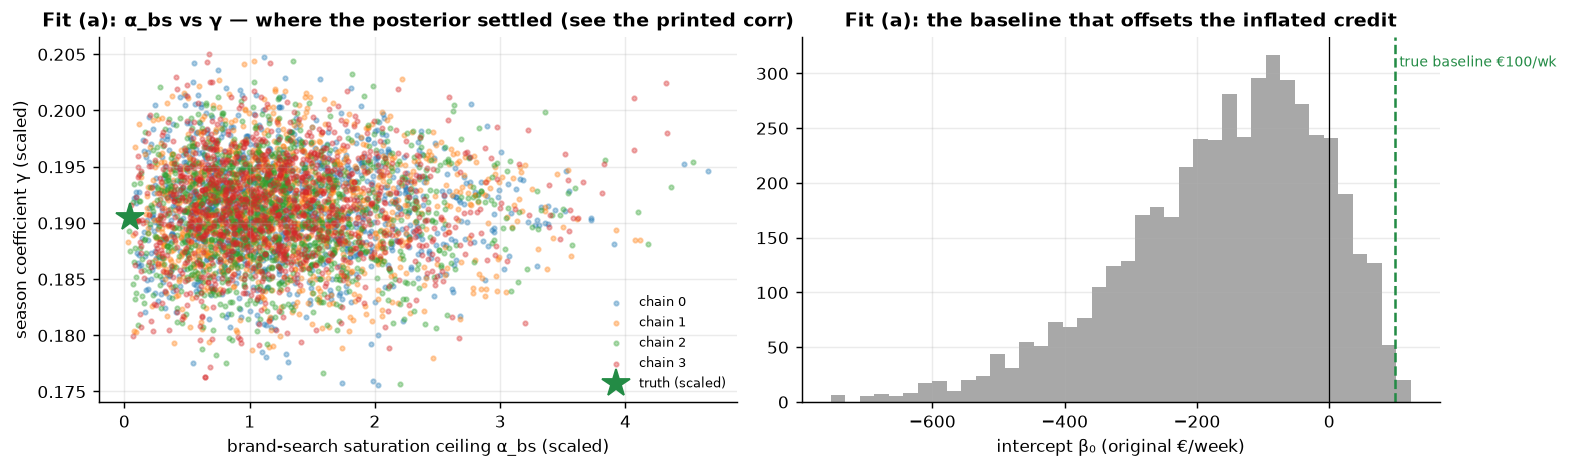

In [10]:
# Evidence for the three claims of the cell above — computed, not asserted.
# (i) the collinearity: spend vs the confounder
print("spend–confounder correlations (the tv row is the contrast):")
print(df[["tv", "brand_search", "seasonality"]].corr().round(2).to_string())

y_max = float(np.abs(y).max())        # pymc-marketing max-abs-scales the target; used to un-scale below
post_d = idata_def.posterior
a_bs_d = post_d["saturation_alpha"].sel(channel="brand_search")   # brand-search ceiling (scaled units)
gam_d = post_d["gamma_control"].isel(control=0)                   # seasonality coefficient (scaled units)

fig, ax = plt.subplots(1, 2, figsize=(12.2, 3.7))
# (ii) the posterior ridge: each dot is one draw of (ceiling, season coefficient), coloured by chain
for c in range(post_d.sizes["chain"]):
    ax[0].scatter(a_bs_d.isel(chain=c).values, gam_d.isel(chain=c).values, s=6, alpha=0.35,
                  label=f"chain {c}")
ax[0].plot([8 / y_max], [35 / y_max], "*", color=plots.GREEN, ms=16, label="truth (scaled)")
ax[0].set_xlabel("brand-search saturation ceiling α_bs (scaled)")
ax[0].set_ylabel("season coefficient γ (scaled)")
ax[0].set_title("Fit (a): α_bs vs γ — where the posterior settled (see the printed corr)")
ax[0].legend(frameon=False, fontsize=7)
# (iii) the baseline that pays for the stolen credit
ic_d = post_d["intercept"].values.ravel() * y_max
ax[1].hist(ic_d, bins=40, color=plots.GREY, alpha=0.85)
ax[1].axvline(100, color=plots.GREEN, ls="--", lw=1.4)
ax[1].text(100, ax[1].get_ylim()[1] * 0.92, " true baseline €100/wk", fontsize=8, color=plots.GREEN)
ax[1].axvline(0, color="k", lw=0.7)
ax[1].set_xlabel("intercept β₀ (original €/week)")
ax[1].set_title("Fit (a): the baseline that offsets the inflated credit")
fig.tight_layout()

rho = float(np.corrcoef(a_bs_d.values.ravel(), gam_d.values.ravel())[0, 1])
ch_means = a_bs_d.mean(dim="draw").values
print(f"\ndraw-level corr(α_bs, γ) = {rho:+.2f}   ·   per-chain α_bs posterior means: {np.round(ch_means, 2)}")
print(f"truth in scaled units: α_bs ≈ {8 / y_max:.3f}, γ ≈ {35 / y_max:.3f} — the green star, far from the mass.")
print(f"intercept (original scale): mean €{ic_d.mean():,.0f}/week vs planted baseline €100/week"
      + ("  -> NEGATIVE: the level decomposition is broken." if ic_d.mean() < 0
         else "  -> dragged far below the truth: the level decomposition is strained."))
if ch_means.max() / max(ch_means.min(), 1e-9) > 2:
    print("Note the per-chain means: the chains sit on DIFFERENT stretches of the ridge — each found its own\n"
          "split of the same wave and never reconciled. That is the R-hat warning above, drawn as a picture.")

**Read-out.** *Left*: every dot is a posterior draw of (brand-search ceiling $\alpha_{bs}$, season
coefficient $\gamma$). The truth (green star) has a tiny ceiling; the posterior sits nowhere near it,
parked in one high-ceiling corner. Now read the number printed under the figure rather than the shape
of the cloud, because at FULL settings it refuses to tell the tidy story: `corr(α_bs, γ) ≈ 0`, and the
four chains agree on $\alpha_{bs}$ to within a few percent. **In this projection the two parameters are
not visibly trading the wave back and forth — the cloud is a blob, not a diagonal.** That is *not*
evidence that the model is identified. It is what a near-flat likelihood looks like once the sampler
has settled into one corner of it: nothing pulls the draws back across the flat direction, so nothing
traces out a diagonal. (At FAST settings, with short chains, the split is cruder and does show: whole
chains land on different $\alpha_{bs}$ — the code's chain-split warning fires there and not here.)

The flatness itself is proved — decisively, and by other output. §4c's posterior predictive check
scores the default and calibrated decompositions, an **order of magnitude apart on brand_search**,
as equally good fits to the *same* series: 89% vs 90% band coverage, RMSE 3.9 vs 3.9. The likelihood
cannot tell them apart. That is the ridge, in the only form the data will show it to us.

*Right*: to pay for the inflated brand-search credit, the intercept is dragged far below the planted
€100/week — the classic broken level decomposition of a non-identified MMM, exactly the "large
negative baseline" claimed above. When two regressors carry the same wave, the likelihood does not
prefer one split over another, and under the default priors the flexible saturation curve books the
credit. **No amount of extra sampling fixes this — only information from outside the dataset can.**
Which is the move of the next section.

### The fix — priors calibrated from a geo experiment

The standard remedy is exactly the discipline of Anchor B (the cookbook's 'calibrate MMMs with experiments' rule, nb 07): run a **small geo experiment** — which randomizes a channel's spend across matched groups of regions (some markets get the ads, some don't) and reads the sales gap as that channel's *true* incremental lift, uncontaminated by the seasonality the observational data can't net out (full treatment in nb 07) — to learn
that brand_search's *incremental* effect is small, and feed that back as an **informative prior on its
saturation ceiling** (`saturation_alpha`). TV, whose incremental role we haven't independently pinned down,
keeps a weakly-informative prior. This is not putting a thumb on the scale — it's using experimental
evidence exactly where observational data is silent.

**From experimental euros to a prior — the mapping, explicitly.** The geo test (nb 07) delivers an
estimate of brand-search's total incremental sales over its test window, $\hat L \pm \mathrm{SE}$.
The MMM says brand-search's weekly contribution at the observed operating point is
$f(\bar a) = \alpha_{bs}\,\bar a / (\kappa_{bs} + \bar a)$, with $\bar a$ the typical adstocked
spend. Matching the model to the experiment therefore pins the ceiling:

$$
\alpha_{bs} \;\approx\; \underbrace{\frac{\hat L}{n_{\text{weeks}}}}_{\text{weekly lift the test measured}}
\cdot\; \underbrace{\frac{\kappa_{bs} + \bar a}{\bar a}}_{\text{ceiling from the operating point}} ,
\qquad\qquad
\alpha^{(s)}_{bs} \sim \mathrm{Gamma}\big(\mu = 0.3,\ \sigma = 0.15\big),
$$

with $\sigma$ scaled from the experiment's SE — wide enough that the MMM's data may still disagree,
tight enough to break the ridge. One unit convention to keep straight: pymc-marketing fits on
**max-abs-scaled** spend and sales, so the prior acts on
$\alpha^{(s)}_{bs} = \alpha_{bs} / \max_t(\text{sales}_t)$ — which is why the 0.3 is not comparable
to the DGP's $\alpha_{bs} = 8$ (sales units) without that conversion. A mean of 0.3 says "the test
showed brand search can move at most a modest fraction of peak weekly sales"; TV keeps the default
$\mathrm{Gamma}(\mu = 2, \sigma = 1)$ — an implied ceiling near *twice* peak weekly sales, i.e.
essentially unconstrained, honest about the fact that no experiment has pinned TV down. Step 5's
sensitivity sweep then shows the conclusion survives anywhere in the experiment-plausible range —
the answer to "didn't you just pick the prior you wanted?".

> **Production note.** pymc-marketing can also ingest the experiment *directly*:
> `MMM.add_lift_test_measurements(df_lift)` appends each lift measurement to the likelihood as a
> distance penalty on the saturation curve's rise over the test's spend delta — a cleaner,
> multi-test-ready alternative to hand-translating one experiment into one Gamma prior, and the
> recommended pattern outside the classroom.

In [11]:
mc = dict(mmm_default.default_model_config)
# channel order = [tv, brand_search]: TV weakly-informative; brand_search's saturation ceiling pinned
# small, as a geo experiment would tell us. This is the load-bearing, experiment-informed prior.
mc["saturation_alpha"] = Prior("Gamma", mu=[2.0, 0.3], sigma=[1.0, 0.15], dims="channel")
mmm = make_mmm(model_config=mc)
idata_cal = mmm.fit(X, y, random_seed=SEED, progressbar=False, **NUTS, **DRAWS)
print(f"(b) calibrated-prior MMM convergence: {est.convergence_report(idata_cal)['summary']}")
contrib = mmm.compute_channel_contribution_original_scale().sum(dim="date")
tv_post = contrib.sel(channel="tv").values.ravel(); bs_post = contrib.sel(channel="brand_search").values.ravel()
print(f"(b) calibrated contribution — TV {tv_post.mean():,.0f}   brand_search {bs_post.mean():,.0f}")
print(f"    true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f}  ->  ranking RESTORED: TV above brand_search.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 4 chains for 2_000 tune and 1_200 draw iterations (8_000 + 4_800 draws total) took 777 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(b) calibrated-prior MMM convergence: max r-hat 1.010 - min ESS 376 - divergences 0
(b) calibrated contribution — TV 12,820   brand_search 2,262
    true: TV 5,263, brand_search 518  ->  ranking RESTORED: TV above brand_search.


## 5 · Validate — fit vs identification, the correction, recovery, and robustness

Six views, from "does it fit?" to "does the conclusion survive?":

1. **Posterior predictive check, both fits** — and the deliberately uncomfortable punchline that
   *fit quality cannot arbitrate between the inverted and the calibrated decomposition*.

2. **The confounding correction, several ways** — naive OLS (omit season) over-credits brand_search; OLS
   **+ season** collapses it toward truth; the **default** causal MMM *inverts* it; the **calibrated** MMM
   restores the right ranking. The contrast between the two MMMs is the headline.
3. **ROAS with uncertainty (calibrated MMM)** — each channel's posterior ROAS vs the break-even line. ROAS = contribution ÷ (fixed **observed** spend), so it carries the **same relative miscalibration as
   the contribution** — dividing by a constant spend cannot remove the bias. What is robust is the ROAS
   **ranking** (and brand_search's below-break-even verdict), **not** the absolute ROAS *levels*, which are
   biased by the same factor as the contributions.
4. **Saturation curves** — contribution vs spend per channel, showing diminishing returns (the shape that
   sets *marginal* ROI and hence where the next euro should go).
5. **Parameter recovery vs the planted truth** — grade the *parameters*, not just the contributions,
   to see exactly where the non-identification lives (and why the calibrated prior is surgical).
6. **Prior sensitivity** — the fix as a robustness *range*, not a single hand-picked point.

Then **5x** closes the section by putting the three estimators — Step 0's classical MMM, the default
Bayesian MMM and the calibrated one — side by side on the same estimand, and asking what the
posterior actually bought (and what it did not).

### View 1 — the posterior predictive check that cannot save you

Before reading any decomposition off either fit, we ask the standard model-criticism question
(nb 01, Step 4): *can the model reproduce the data it was trained on?* For each fit we draw
replicated sales series from the posterior predictive, lay the replicates' 5–95% band over the
observed series, and print the share of observed weeks inside the band (≈90% means calibrated).
Watch for what does **not** happen: the model with the inverted, wildly wrong decomposition does
not fit any worse.

Sampling: [y]


Sampling: [y]


share of observed weeks inside the 5–95% replicate band — default 89% · calibrated 90%   (nominal ≈ 90%)
replicate-mean RMSE (€/week)                              — default 3.9 · calibrated 3.9   (DGP noise σ = 4)
Two decompositions that disagree by an order of magnitude on brand_search reproduce the observed
sales series near-identically — the likelihood cannot tell them apart. The ridge is where they hide.


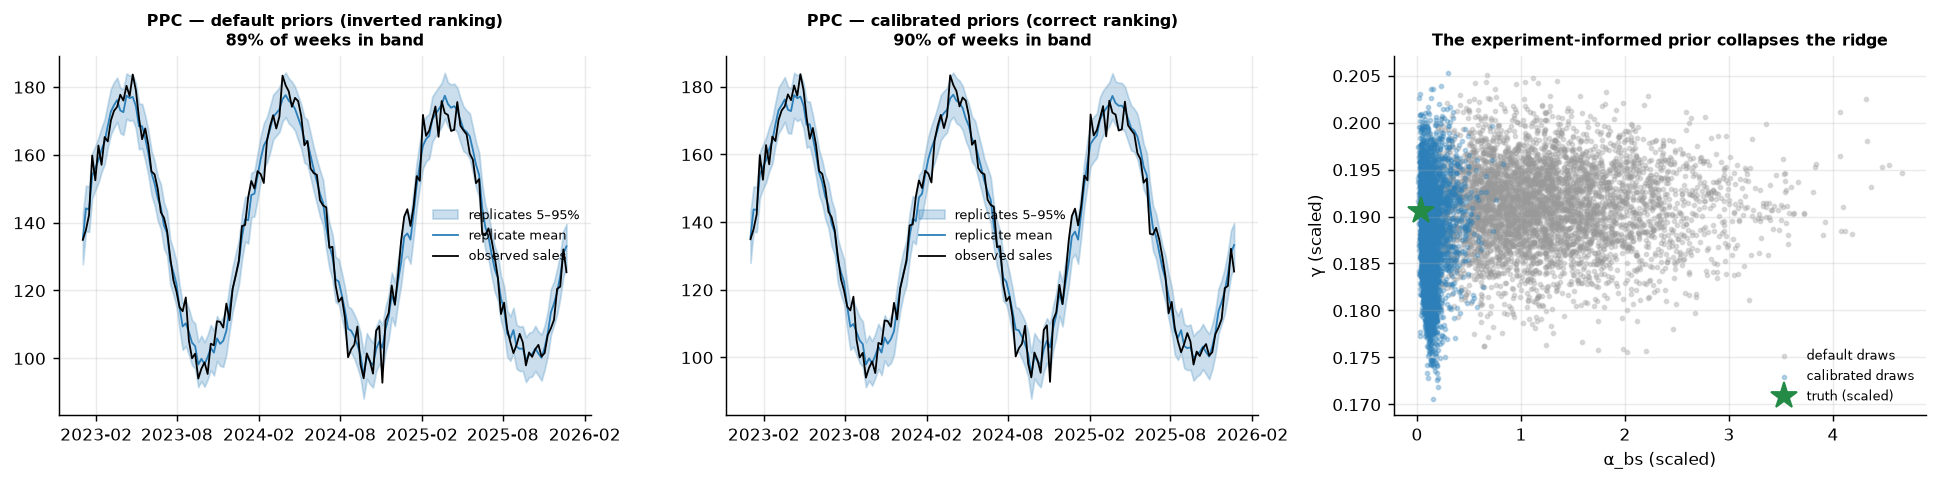

In [12]:
def ppc_band(m, seed=SEED):
    ds = m.sample_posterior_predictive(X, extend_idata=True, combined=True, original_scale=True,
                                       random_seed=seed, progressbar=False)
    yr = ds["y"].values
    if ds["y"].dims[0] == "sample":            # normalise to (date, sample)
        yr = yr.T
    lo, hi = np.quantile(yr, [0.05, 0.95], axis=1)
    cov = float(np.mean((y.values >= lo) & (y.values <= hi)))
    rmse = float(np.sqrt(np.mean((yr.mean(axis=1) - y.values) ** 2)))
    return yr.mean(axis=1), lo, hi, cov, rmse

covs, rmses = {}, {}
fig, ax = plt.subplots(1, 3, figsize=(15.0, 3.8))
for a, (key, ttl, m) in zip(ax[:2], [("default", "default priors (inverted ranking)", mmm_default),
                                     ("calibrated", "calibrated priors (correct ranking)", mmm)]):
    mu_r, lo, hi, cov, rmse = ppc_band(m)
    covs[key], rmses[key] = cov, rmse
    a.fill_between(df["date_week"], lo, hi, color=plots.BLUE, alpha=0.25, label="replicates 5–95%")
    a.plot(df["date_week"], mu_r, color=plots.BLUE, lw=1.0, label="replicate mean")
    a.plot(df["date_week"], y.values, color="k", lw=1.0, label="observed sales")
    a.set_title(f"PPC — {ttl}\n{cov:.0%} of weeks in band", fontsize=9)
    a.legend(frameon=False, fontsize=7)
# third panel: what the calibrated prior did to the ridge of the previous section
y_max = float(np.abs(y).max())
for idt, col, lab in [(idata_def, plots.GREY, "default draws"), (idata_cal, plots.BLUE, "calibrated draws")]:
    ax[2].scatter(idt.posterior["saturation_alpha"].sel(channel="brand_search").values.ravel(),
                  idt.posterior["gamma_control"].isel(control=0).values.ravel(),
                  s=5, alpha=0.3, color=col, label=lab)
ax[2].plot([8 / y_max], [35 / y_max], "*", color=plots.GREEN, ms=15, label="truth (scaled)")
ax[2].set_xlabel("α_bs (scaled)"); ax[2].set_ylabel("γ (scaled)")
ax[2].set_title("The experiment-informed prior collapses the ridge", fontsize=9)
ax[2].legend(frameon=False, fontsize=7)
import matplotlib.dates as mdates
for a in ax[:2]:
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.tight_layout()
print(f"share of observed weeks inside the 5–95% replicate band — default {covs['default']:.0%} · "
      f"calibrated {covs['calibrated']:.0%}   (nominal ≈ 90%)")
print(f"replicate-mean RMSE (€/week)                              — default {rmses['default']:.1f} · "
      f"calibrated {rmses['calibrated']:.1f}   (DGP noise σ = 4)")
print("Two decompositions that disagree by an order of magnitude on brand_search reproduce the observed")
print("sales series near-identically — the likelihood cannot tell them apart. The ridge is where they hide.")

**Read-out.** The two left panels are, for practical purposes, the same picture: near-identical
bands, coverage and RMSE (printed above) — yet the left model credits brand_search with tens of
times its true contribution. This is the precise sense in which the notebook's failure is
**identification, not fit**: the generator uses the MMM's own functional form (Step 2's
"well-specified" remark), so both fits sit near the same likelihood value, and no amount of
posterior-predictive checking can distinguish the inverted decomposition from the correct one. Keep
running PPCs — a model that *cannot* reproduce the series is disqualified before you read anything
off it — but treat them as **necessary, never sufficient** for a causal claim. *Right panel*: what
the experiment-informed prior actually did. The default posterior (grey) spreads along the ridge;
the calibrated posterior (blue) is pinned at the low-ceiling end, beside the truth. The prior did
not overrule the data — it **selected among answers the data could not rank**.

brand_search credit — naive 6,401 | OLS+season 222 | MMM default 36,007 | MMM calibrated 2,262 | true 518
calibrated ROAS — TV 2.08× [90% 0.34,8.67]  ·  brand_search 0.60× [90% 0.11,2.28]
TRUE ROAS       — TV 0.85× · brand_search 0.14×  (both below 1×: the MMM recovers the ranking but overstates levels)


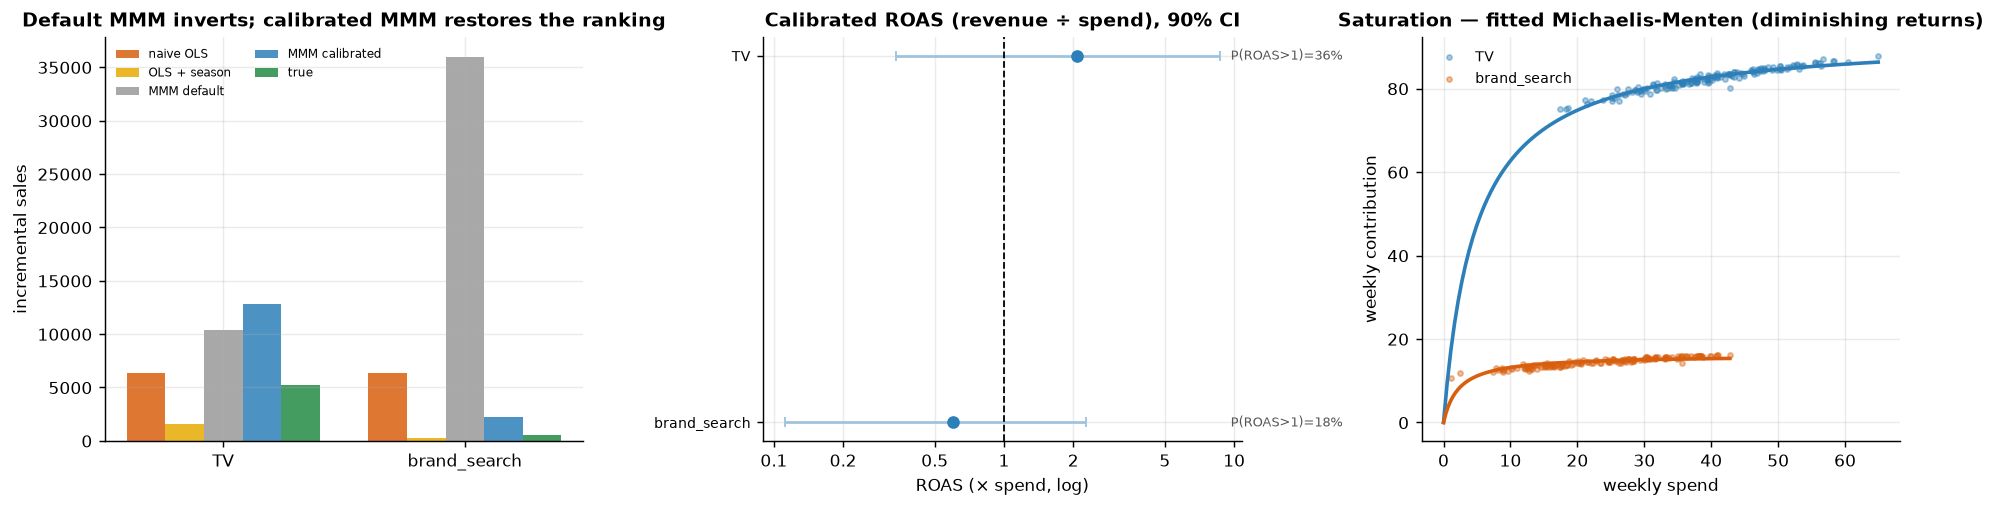

In [13]:
def credit(cols):
    Xn = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    b, *_ = np.linalg.lstsq(Xn, df["sales"].values, rcond=None)
    c = dict(zip(cols, b[1:])); return c["tv"]*df["tv"].sum(), c["brand_search"]*df["brand_search"].sum()
naive_tv, naive_bs = credit(["tv","brand_search"])
adj_tv, adj_bs = credit(["tv","brand_search","seasonality"])
spend_tv, spend_bs = df["tv"].sum(), df["brand_search"].sum()
roi_tv, roi_bs = tv_post/spend_tv, bs_post/spend_bs      # ROAS = revenue ÷ spend (calibrated MMM drives the decision)

fig, ax = plt.subplots(1, 3, figsize=(14.8, 4))
# (1) confounding correction — five estimators, GREY = the failure-mode default MMM
labels = ["TV","brand_search"]; x = np.arange(2); w = 0.16
series = [("naive OLS", [naive_tv,naive_bs], plots.ORANGE),
          ("OLS + season", [adj_tv,adj_bs], plots.GOLD),
          ("MMM default", [tv_def.mean(),bs_def.mean()], plots.GREY),
          ("MMM calibrated", [tv_post.mean(),bs_post.mean()], plots.BLUE),
          ("true", [true_tv,true_bs], plots.GREEN)]
for i,(lab,vals,col) in enumerate(series):
    ax[0].bar(x + (i-2)*w, vals, w, color=col, alpha=0.85, label=lab)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].legend(frameon=False, fontsize=6.5, ncol=2)
ax[0].set_ylabel("incremental sales"); ax[0].set_title("Default MMM inverts; calibrated MMM restores the ranking")
# (2) ROI forest (calibrated MMM)
plots.forest_plot(ax[1], ["TV","brand_search"], [roi_tv.mean(),roi_bs.mean()],
    [np.quantile(roi_tv,.05),np.quantile(roi_bs,.05)], [np.quantile(roi_tv,.95),np.quantile(roi_bs,.95)],
    ref=1.0, title="Calibrated ROAS (revenue ÷ spend), 90% CI", xlabel="ROAS (× spend, log)",
    logx=True, annot=[f"P(ROAS>1)={(roi_tv>1).mean():.0%}", f"P(ROAS>1)={(roi_bs>1).mean():.0%}"])
import matplotlib.ticker as mtick
ax[1].xaxis.set_major_locator(mtick.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))  # readable log ticks
ax[1].xaxis.set_major_formatter(mtick.FormatStrFormatter("%g"))
ax[1].xaxis.set_minor_locator(mtick.NullLocator())
# (3) saturation: weekly contribution vs weekly spend (calibrated MMM)
cw = mmm.compute_channel_contribution_original_scale().mean(dim=["chain","draw"])
ax[2].scatter(df["tv"], cw.sel(channel="tv").values, s=8, alpha=0.4, color=plots.BLUE, label="TV")
ax[2].scatter(df["brand_search"], cw.sel(channel="brand_search").values, s=8, alpha=0.4, color=plots.ORANGE, label="brand_search")
# overlay the fitted Michaelis-Menten saturation curve a*x/(b+x) per channel (not just the point cloud)
from scipy.optimize import curve_fit
def _mm(x, a, b): return a * x / (b + x)
for _chan, _col in [("tv", plots.BLUE), ("brand_search", plots.ORANGE)]:
    _xs = df[_chan].values; _ys = cw.sel(channel=_chan).values
    try:
        (_a, _b), _ = curve_fit(_mm, _xs, _ys, p0=[max(_ys.max(), 1.0), np.median(_xs) + 1e-9],
                                bounds=(0, np.inf), maxfev=20000)
        _gx = np.linspace(0, _xs.max(), 120)
        ax[2].plot(_gx, _mm(_gx, _a, _b), color=_col, lw=2)
    except Exception:
        pass
ax[2].set_xlabel("weekly spend"); ax[2].set_ylabel("weekly contribution"); ax[2].set_title("Saturation — fitted Michaelis-Menten (diminishing returns)"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"brand_search credit — naive {naive_bs:,.0f} | OLS+season {adj_bs:,.0f} | MMM default {bs_def.mean():,.0f} | MMM calibrated {bs_post.mean():,.0f} | true {true_bs:,.0f}")
print(f"calibrated ROAS — TV {roi_tv.mean():.2f}× [90% {np.quantile(roi_tv,.05):.2f},{np.quantile(roi_tv,.95):.2f}]  ·  "
      f"brand_search {roi_bs.mean():.2f}× [90% {np.quantile(roi_bs,.05):.2f},{np.quantile(roi_bs,.95):.2f}]")
tr_tv, tr_bs = true_tv/spend_tv, true_bs/spend_bs
print(f"TRUE ROAS       — TV {tr_tv:.2f}× · brand_search {tr_bs:.2f}×  (both below 1×: the MMM recovers the ranking but overstates levels)")

**How to read this.** *Left* tells the whole story in one panel. **Naive OLS** (orange) over-credits
brand_search; **OLS + season** (gold) collapses that credit toward the small truth — the confounding
correction, working. Then the two MMMs: the **default** causal MMM (grey, the failure mode) *inverts* the
ranking, crediting brand_search far above TV — the seasonal-demand-stealing trap — while the **calibrated**
MMM (blue) restores TV above brand_search, landing beside the **true** bars (green). *Middle* — the
decision-relevant **calibrated ROAS**: TV's mean clears break-even but its 90% interval is wide and dips
below 1×, while brand_search's mean sits **below break-even**. So TV is the better channel, but its
above-break-even verdict is itself uncertain. And the ranking is only *probably* right: draw-by-draw, TV's
ROAS beats brand_search's about **78%** of the time in the committed FULL run (the `P(TV ROAS > brand_search ROAS)` computed in Step 6) —
more likely than not, but **short of the 0.8 bar** we'd want before moving real budget. *Right* — the
**saturation curves**: contribution flattens as spend rises (diminishing returns), so the *next* euro into a
channel is worth its curve's *slope*, not its average. The honest caveat (Step 7): even the calibrated ROAS
*levels* are approximate — anchor them with the same kind of geo experiment that supplied the prior.

### View 5 — grade the parameters, not just the contributions

Step 2 planted $\lambda = (0.4,\, 0.2)$, $\alpha = (60,\, 8)$, $\kappa = (50,\, 40)$, a baseline of
100 and a season coefficient of 35 — and the MMM estimates those same quantities, so we can grade
them directly (the cookbook's validation-first premise). One bookkeeping step first: the fitted
parameters live in max-abs-scaled units behind a *normalized* adstock, so we map each posterior
draw back to original units before comparing — the ceiling as
$\hat\alpha_c = \alpha^{(s)}_c \cdot \max_t(\text{sales}_t)$, the half-saturation as
$\hat\kappa_c = \kappa^{(s)}_c \cdot \max_t(x_{c,t}) \cdot S(\hat\lambda_c)$ where
$S(\lambda) = \sum_{\ell=0}^{7} \lambda^{\ell}$ is the adstock normalizer, and the decay
$\lambda_c$ compares as-is (it is scale-free). The question the table answers is not "are the
numbers perfect?" (they will not be — Step 4's caution about levels applies to parameters too) but
**where the error concentrates**.

In [14]:
y_max = float(np.abs(y).max())
TRUTH = {"tv": {"adstock decay": 0.40, "ceiling (€/wk)": 60.0, "half-sat (€)": 50.0},
         "brand_search": {"adstock decay": 0.20, "ceiling (€/wk)": 8.0, "half-sat (€)": 40.0}}

def implied_params(idt, ch):
    lam = idt.posterior["adstock_alpha"].sel(channel=ch).values.ravel()
    S = (1 - lam ** 8) / (1 - lam)                                   # adstock normalizer, l_max = 8
    return {"adstock decay": lam,
            "ceiling (€/wk)": idt.posterior["saturation_alpha"].sel(channel=ch).values.ravel() * y_max,
            "half-sat (€)": idt.posterior["saturation_lam"].sel(channel=ch).values.ravel()
                            * float(np.abs(df[ch]).max()) * S}

def _fmt(d):
    return f"{d.mean():.3g} [{np.quantile(d, .05):.3g}, {np.quantile(d, .95):.3g}]"

rows = []
for ch in ["tv", "brand_search"]:
    pdft, pcal = implied_params(idata_def, ch), implied_params(idata_cal, ch)
    for par in TRUTH[ch]:
        rows.append({"channel": ch, "parameter": par, "true": TRUTH[ch][par],
                     "default": _fmt(pdft[par]), "calibrated": _fmt(pcal[par])})
for nm, tru, pick in [("baseline (€/wk)", 100.0, lambda idt: idt.posterior["intercept"].values.ravel() * y_max),
                      ("season (€/wk)", 35.0,
                       lambda idt: idt.posterior["gamma_control"].isel(control=0).values.ravel() * y_max)]:
    rows.append({"channel": "—", "parameter": nm, "true": tru,
                 "default": _fmt(pick(idata_def)), "calibrated": _fmt(pick(idata_cal))})
print("Parameter recovery per fit — cells show posterior mean [90% CI];")
print("season coeff is EUR/wk per unit s_t.\n")
print(pd.DataFrame(rows).to_string(index=False))

ceil_d = implied_params(idata_def, "brand_search")["ceiling (€/wk)"].mean()
ceil_c = implied_params(idata_cal, "brand_search")["ceiling (€/wk)"].mean()
print(f"\nWhere the error concentrates: brand_search's fitted ceiling is ~{ceil_d / 8:.0f}×")
print(f"its true value under default priors, and ~{ceil_c / 8:.0f}× under the calibrated")
print("prior — the calibration acts on exactly the one parameter the data cannot")
print("pin down. TV's curve parameters stay loosely identified in BOTH fits (read")
print("the CIs above) — which is why Step 6 trusts the ranking, never the levels.")

Parameter recovery per fit — cells show posterior mean [90% CI];
season coeff is EUR/wk per unit s_t.

     channel       parameter  true               default            calibrated
          tv   adstock decay   0.4 0.234 [0.0473, 0.416] 0.223 [0.0416, 0.411]
          tv  ceiling (€/wk)  60.0       103 [43.9, 294]       114 [42.6, 353]
          tv    half-sat (€)  50.0      92.4 [1.72, 232]      81.3 [1.29, 222]
brand_search   adstock decay   0.2 0.351 [0.0645, 0.672] 0.336 [0.0388, 0.672]
brand_search  ceiling (€/wk)   8.0       232 [58.2, 478]        23.2 [7.9, 57]
brand_search    half-sat (€)  40.0   0.91 [0.0116, 1.37]      60.8 [0.39, 178]
           — baseline (€/wk) 100.0     -160 [-450, 50.8]        41 [-222, 119]
           —   season (€/wk)  35.0     35.1 [33.7, 36.4]         34.5 [33, 36]

Where the error concentrates: brand_search's fitted ceiling is ~29×
its true value under default priors, and ~3× under the calibrated
prior — the calibration acts on exactly the one par

**Read-out.** The table closes the loop on Step 4b's "not a thumb on the scale" claim. The default
fit's damage is *concentrated*: brand-search's ceiling — the parameter that can impersonate the
seasonal wave — inflates by an order of magnitude or more, and the level account is dragged along to offset
the inflated credit — read the baseline row, far from the planted 100. The calibrated prior moves **that one
number** back toward the truth and leaves every other parameter to the data — surgical, because the
experiment spoke to exactly the quantity the likelihood is silent about. Note also what calibration
does *not* fix: TV's ceiling and half-saturation remain wide and level-shifted in both fits.
Rankings, not levels — the caution of Step 4 holds at the parameter level too.

### View 6 — "didn't you just choose the prior that gives the answer you wanted?"

The skeptic's question, and it deserves a computed answer rather than a shrug. We refit the MMM
across a grid of prior means for brand-search's saturation ceiling — from half our calibrated value
up to the library default — keeping the same Gamma shape family throughout
($\mu_{bs} \in \{0.15, 0.3, 0.6, 1.0, 2.0\}$ in scaled units, $\sigma = \mu/2$). The 0.3 and 2.0
grid points *are* the two headline fits, reused rather than refit; the three new fits run at
**ranking-grade sampler settings** (short chains — stable posterior means and ranking
probabilities, not interval-grade diagnostics, exactly like notebook 01's stability sweep), so this
cell stays cheap in both FAST and FULL profiles. Two curves to read: each channel's estimated
contribution as the prior loosens, and $P(\text{contrib}_{tv} > \text{contrib}_{bs})$ against the
0.5 line (ranking flips) and the 0.8 action bar.

Output()

Output()

Output()

Ranking verdict across the sweep: correct (P > 0.5) for μ_bs ≤ 0.3; flipped by μ_bs = 0.6.
The geo experiment would have to be wrong by ~2× before the conclusion moved.
(Sweep fits are ranking-grade short chains: read the means and the flip point, not intervals.)


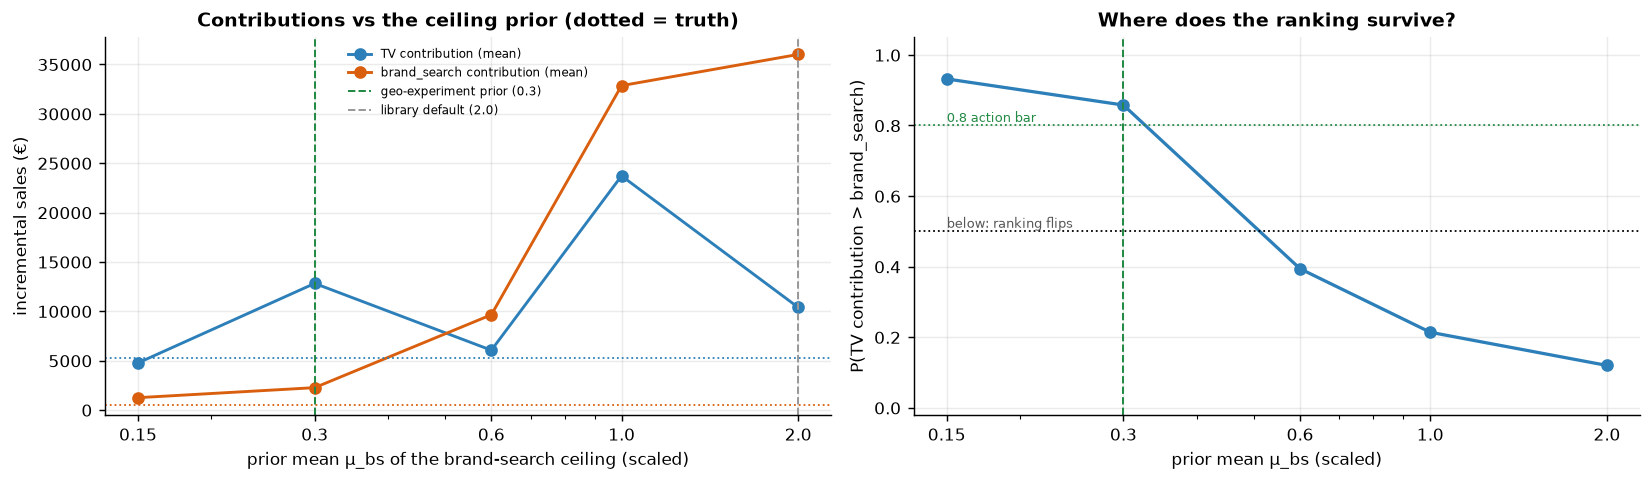

In [15]:
# Three refits would each spew a page of sampler chatter; silence the pymc logger for this cell
# (CRITICAL+1 because SamplerWarnings log at ERROR level). The convergence question for these
# ranking-grade fits is handled by design: we read only means and ranking probabilities.
import logging, pymc
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)

MUS = [0.15, 0.3, 0.6, 1.0, 2.0]
sweep = {0.3: (tv_post, bs_post),     # reuse fit (b): Gamma(mu=0.3, sigma=0.15) on brand_search
         2.0: (tv_def, bs_def)}       # reuse fit (a): the library default Gamma(mu=2, sigma=1)
for mu_bs in MUS:
    if mu_bs in sweep:
        continue
    mcs = dict(mmm_default.default_model_config)
    mcs["saturation_alpha"] = Prior("Gamma", mu=[2.0, mu_bs], sigma=[1.0, mu_bs / 2], dims="channel")
    ms = make_mmm(model_config=mcs)
    ms.fit(X, y, random_seed=SEED, progressbar=False, target_accept=0.9, **SWEEP_DRAWS)
    cs = ms.compute_channel_contribution_original_scale().sum(dim="date")
    sweep[mu_bs] = (cs.sel(channel="tv").values.ravel(), cs.sel(channel="brand_search").values.ravel())

mus = np.array(MUS)
tv_sw = np.array([sweep[m][0].mean() for m in MUS])
bs_sw = np.array([sweep[m][1].mean() for m in MUS])
p_rank = np.array([(sweep[m][0] > sweep[m][1]).mean() for m in MUS])

fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.8))
ax[0].plot(mus, tv_sw, "o-", color=plots.BLUE, lw=1.6, label="TV contribution (mean)")
ax[0].plot(mus, bs_sw, "o-", color=plots.ORANGE, lw=1.6, label="brand_search contribution (mean)")
ax[0].axhline(true_tv, color=plots.BLUE, ls=":", lw=1); ax[0].axhline(true_bs, color=plots.ORANGE, ls=":", lw=1)
ax[0].axvline(0.3, color=plots.GREEN, ls="--", lw=1.1, label="geo-experiment prior (0.3)")
ax[0].axvline(2.0, color=plots.GREY, ls="--", lw=1.1, label="library default (2.0)")
ax[0].set_xscale("log"); ax[0].set_xticks(mus); ax[0].set_xticklabels([str(m) for m in MUS])
ax[0].set_xlabel("prior mean μ_bs of the brand-search ceiling (scaled)"); ax[0].set_ylabel("incremental sales (€)")
ax[0].set_title("Contributions vs the ceiling prior (dotted = truth)"); ax[0].legend(frameon=False, fontsize=6.5)
ax[1].plot(mus, p_rank, "o-", color=plots.BLUE, lw=1.8)
ax[1].axhline(0.5, color="k", ls=":", lw=1); ax[1].axhline(0.8, color=plots.GREEN, ls=":", lw=1)
ax[1].text(mus[0], 0.51, "below: ranking flips", fontsize=7, color="#555555")
ax[1].text(mus[0], 0.81, "0.8 action bar", fontsize=7, color=plots.GREEN)
ax[1].axvline(0.3, color=plots.GREEN, ls="--", lw=1.1)
ax[1].set_xscale("log"); ax[1].set_xticks(mus); ax[1].set_xticklabels([str(m) for m in MUS])
ax[1].set_ylim(-0.02, 1.05); ax[1].set_xlabel("prior mean μ_bs (scaled)")
ax[1].set_ylabel("P(TV contribution > brand_search)")
ax[1].set_title("Where does the ranking survive?")
for a in ax:
    a.xaxis.set_minor_formatter(plt.NullFormatter())
fig.tight_layout()

mus_ok = mus[p_rank > 0.5]; mus_flip = mus[p_rank <= 0.5]
if len(mus_ok) and len(mus_flip):
    print(f"Ranking verdict across the sweep: correct (P > 0.5) for μ_bs ≤ {mus_ok.max():g}; flipped by "
          f"μ_bs = {mus_flip.min():g}.")
    print(f"The geo experiment would have to be wrong by ~{mus_flip.min() / 0.3:.0f}× before the conclusion moved.")
elif len(mus_ok) == len(mus):
    print("Ranking verdict: correct at every grid point in this run — at these sampler settings even the")
    print("default prior did not flip it (the FULL-strength default fit above did; short chains wobble).")
else:
    print("Ranking verdict: flipped at every grid point in this run — re-run at FULL settings before reading.")
print("(Sweep fits are ranking-grade short chains: read the means and the flip point, not intervals.)")

**Read-out — and read the printed line, not the hope.** The conclusion is not an artifact of *one*
hand-set prior, but the margin around it is narrow and the sweep says exactly how narrow. In the
committed FULL run the ranking is correct ($P > 0.5$) only for $\mu_{bs} \le 0.3$ and is **already
flipped at the very next grid point**, $\mu_{bs} = 0.6$ — three of the five grid points invert
(`p_tv_beats_bs` falls 0.93 → 0.86 → 0.39 → 0.21 → 0.12). It does *not* hold across the whole
experiment-plausible range, and it does *not* survive until the library default at 2.0.

So state the robustness as the number it is: **about twofold in the prior mean, and that is all.**
A real geo test would have to have been wrong by roughly a factor of two on brand search's ceiling —
not by a few percent, but not by much more than double either — before this budget decision changed
direction. The left panel is the honest dial: loosening the prior slides brand-search's contribution
smoothly from near its dotted truth line back up toward the flat likelihood's preferred answer, with
the data pushing back only weakly anywhere along the way. That gentleness *is* the finding. The
likelihood barely resists, so the prior's strength maps almost one-for-one onto the conclusion —
which is what "the experiment, not the estimator, carries the identification" actually looks like
when you measure it.

### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

Three estimators are now on the table, all targeting the **same estimand** under the **same
identification argument** (backdoor-adjust for seasonality): the classical profiled MMM of Step 0,
the default-prior Bayesian MMM, and the experiment-calibrated Bayesian MMM. Line them up on the same
quantities — contribution, ROAS, the ranking — and on the thing that actually differs: what each is
entitled to *say*.

In [16]:
roas_def_tv, roas_def_bs = tv_def / spend_tv, bs_def / spend_bs      # default-MMM ROAS draws
def _band(v, lo=0.05, hi=0.95):
    return f"{v.mean():,.0f} [{np.quantile(v, lo):,.0f}, {np.quantile(v, hi):,.0f}]"
def _bandx(v):
    return f"{v.mean():.2f} [{np.quantile(v, .05):.2f}, {np.quantile(v, .95):.2f}]"

EST = ["truth", "classical (Step 0)", "MMM default", "MMM calibrated"]
con_rows = [
    {"estimator": "truth", "TV contribution (€)": f"{true_tv:,.0f}",
     "brand_search (€)": f"{true_bs:,.0f}", "ranking": "TV first"},
    {"estimator": "classical (Step 0)",
     "TV contribution (€)": f"{CLS['tv']['contrib']:,.0f} [{CLS['tv']['contrib_ci'][0]:,.0f}, "
                            f"{CLS['tv']['contrib_ci'][1]:,.0f}]",
     "brand_search (€)": f"{CLS['brand_search']['contrib']:,.0f} "
                         f"[{CLS['brand_search']['contrib_ci'][0]:,.0f}, "
                         f"{CLS['brand_search']['contrib_ci'][1]:,.0f}]",
     "ranking": "TV first" if CLS["tv"]["contrib"] > CLS["brand_search"]["contrib"] else "INVERTED"},
    {"estimator": "MMM default", "TV contribution (€)": _band(tv_def),
     "brand_search (€)": _band(bs_def),
     "ranking": "TV first" if tv_def.mean() > bs_def.mean() else "INVERTED"},
    {"estimator": "MMM calibrated", "TV contribution (€)": _band(tv_post),
     "brand_search (€)": _band(bs_post),
     "ranking": "TV first" if tv_post.mean() > bs_post.mean() else "INVERTED"},
]
roas_rows = [
    {"estimator": "truth", "TV ROAS (×)": f"{true_tv / spend_tv:.2f}",
     "brand_search ROAS (×)": f"{true_bs / spend_bs:.2f}"},
    {"estimator": "classical (Step 0)",
     "TV ROAS (×)": f"{CLS['tv']['roas']:.2f} [{CLS['tv']['roas_ci'][0]:.2f}, "
                    f"{CLS['tv']['roas_ci'][1]:.2f}]",
     "brand_search ROAS (×)": f"{CLS['brand_search']['roas']:.2f} "
                              f"[{CLS['brand_search']['roas_ci'][0]:.2f}, "
                              f"{CLS['brand_search']['roas_ci'][1]:.2f}]"},
    {"estimator": "MMM default", "TV ROAS (×)": _bandx(roas_def_tv),
     "brand_search ROAS (×)": _bandx(roas_def_bs)},
    {"estimator": "MMM calibrated", "TV ROAS (×)": _bandx(roi_tv),
     "brand_search ROAS (×)": _bandx(roi_bs)},
]
print("Same estimand, same DAG, three estimators — mean [90% interval]:\n")
print(pd.DataFrame(con_rows).to_string(index=False))
print()
print(pd.DataFrame(roas_rows).to_string(index=False))

# --- what each is entitled to SAY about TV's ROAS ---
tru = true_tv / spend_tv
cls_lo, cls_hi = CLS["tv"]["roas_ci"]
cal_lo, cal_hi = float(np.quantile(roi_tv, .05)), float(np.quantile(roi_tv, .95))
p_tv_first = float((roi_tv > roi_bs).mean())
print(f"\nThe interval on TV's ROAS (true = {tru:.2f}×) — width, coverage, and")
print("what each one conditions on:")
print(f"  classical CI (transform fixed): [{cls_lo:.2f}, {cls_hi:.2f}] width {cls_hi - cls_lo:.2f}"
      f" -> covers truth? {'YES' if cls_lo <= tru <= cls_hi else 'NO'}")
print(f"  + the transform envelope      : [{env_lo:.2f}, {env_hi:.2f}] width {env_w:.2f}"
      f" -> covers truth? {'YES' if env_lo <= tru <= env_hi else 'NO'}")
print("       (Step 0's profile region — the ignorance the CI above hides)")
print(f"  calibrated posterior CrI      : [{cal_lo:.2f}, {cal_hi:.2f}] width {cal_hi - cal_lo:.2f}"
      f" -> covers truth? {'YES' if cal_lo <= tru <= cal_hi else 'NO'}")
print("       (λ and κ integrated out, not fixed by fiat)")
print(f"\nThe decision quantity itself:")
print(f"  posterior P(TV ROAS > brand_search ROAS) = {p_tv_first:.2f}   (vs the 0.8 action bar)")
print(f"  The classical arm has no such number. Its nearest analogue — the")
print(f"  share of the λ,κ settings the fit cannot rule out that rank TV")
print(f"  first — is {reg_rank_ok:.0%}. But that is a statement about a GRID, not a")
print(f"  probability about the channels: it cannot be compared to the 0.8 bar.")


Same estimand, same DAG, three estimators — mean [90% interval]:

         estimator    TV contribution (€)       brand_search (€)  ranking
             truth                  5,263                    518 TV first
classical (Step 0)   2,526 [1,875, 3,178]      528 [-194, 1,249] TV first
       MMM default 10,390 [2,113, 44,033] 36,007 [8,803, 74,287] INVERTED
    MMM calibrated 12,820 [2,096, 53,524]     2,262 [423, 8,596] TV first

         estimator       TV ROAS (×) brand_search ROAS (×)
             truth              0.85                  0.14
classical (Step 0) 0.41 [0.30, 0.51]    0.14 [-0.05, 0.33]
       MMM default 1.68 [0.34, 7.13]    9.54 [2.33, 19.68]
    MMM calibrated 2.08 [0.34, 8.67]     0.60 [0.11, 2.28]

The interval on TV's ROAS (true = 0.85×) — width, coverage, and
what each one conditions on:
  classical CI (transform fixed): [0.30, 0.51] width 0.21 -> covers truth? NO
  + the transform envelope      : [0.30, 3.44] width 3.14 -> covers truth? YES
       (Step 0's 

**The honest verdict, in three beats.**

**1 · Do they agree?** Read the ranking row. The *calibrated* Bayesian MMM ranks TV first, as the
truth does; the *default* Bayesian MMM inverts it; and the classical fit's verdict depends on which
run you are reading — on the committed FULL series it ranks TV first (out-scoring the default MMM,
which is the uncomfortable part, and we said so in Step 0), while on the shorter FAST series the
same estimator inverts. Both of those classical outcomes were produced by *fixing* $(\lambda,
\kappa)$ by fiat: an infinitely strong constraint that in one sample forbade the seasonal-wave theft
and in the other invited it. That is not robustness; it is a coin landing the right way up, and
Step 0's profile region — which contains settings that invert the ranking — is the coin. On *levels*
nobody covers themselves in glory: the classical fit and the calibrated MMM miss the true
contributions in **opposite directions**, by multiples (read the table). Neither is a euro-grade
level estimate, exactly as §6 and §7 insist.

**2 · What the posterior gives you that the point estimate cannot.** Three things, all visible above.
*(i) Uncertainty that includes the transform.* The Bayesian MMM puts a **prior on λ and κ and
integrates over them**, so its interval propagates precisely the ignorance the classical CI
conditions away. Compare the three intervals printed on TV's ROAS: the classical CI is the narrow
one — and it is narrow because it *assumed away* the dominant source of uncertainty; widen it by
hand with Step 0's profile region and you land in the same neighbourhood as the posterior. The
posterior did not "add" uncertainty, it declined to hide it. Which of them contains the truth is
printed above; the narrow one has no monopoly on being right, and every reason to be
over-confident. *(ii) A native channel for experimental evidence.* A geo lift test enters the
Bayesian model as a **prior on the saturation ceiling** — the exact parameter the test measures
(Step 4b) — or, in production, straight into the likelihood via
`add_lift_test_measurements`. The classical analogue is a hard constraint or a ridge penalty on
$\alpha_{bs}$: a prior in disguise, with no honest interval and no principled way to weigh the
test's own standard error against the data. *(iii) The number the budget meeting needs.*
$P(\text{TV ROAS} > \text{brand search ROAS})$ is a posterior probability. It is printed above and
compared to the 0.8 action bar; the classical arm has no such quantity, only a point ranking, which
is why §6's whole euro decision — the shift-size sweep *with its band*, the value of the experiment
— is a Bayesian construction end to end.

**3 · What Bayes did NOT buy.** It did **not** rescue a non-identified model. That is this
notebook's spine and Step 0 sharpens it into a needle: the flat SSE surface of Step 0 and the
near-identical posterior predictive checks of §4c are *the same object seen twice* — one likelihood,
near-flat along the direction that trades brand search's ceiling against the seasonal coefficient.
Note what the evidence for that flatness is and is not: it is **not** the α_bs–γ scatter of §4a,
which at FULL settings prints a draw-level correlation of ≈ 0 and shows no linear trade-off at all;
it is the SSE surface, and it is the PPC, where two decompositions an order of magnitude apart on
brand search score *the same* 89–90% coverage and *the same* RMSE 3.9 against the same series. Being
Bayesian about it changes the failure's shape, not its existence, and with the library's default priors it made it
**worse** (the inverted ranking) — a generous $\mathrm{Gamma}(\mu = 2)$ ceiling prior is an active
invitation to steal the wave, not a neutral abstention. Priors help only when they carry **real
information**. Here exactly one of them did: the geo experiment's prior on
$\alpha_{\text{bs}}$ — and View 6 showed the conclusion tracks that prior's strength, which is the
honest confession that **the experiment, not the estimator, is doing the identifying**. Bayes is what
let the experiment *in*, coherently, with an interval on the other side. It is not what made the
model identified.

## 6 · Decide, in euros — should we reallocate budget yet?

Budget chases **incremental return**, not last-click credit. One naming point first: what the MMM gives us is
**ROAS** — incremental *revenue* per euro of spend — not profit ROI. Break-even at 1× therefore assumes a
100% margin; at a realistic margin *m* the break-even ROAS is **1/m** (a 30% margin → 3.3×), which we show below.

Now that experiment-calibrated priors have made the *ranking* trustworthy, the point estimates put TV above
brand_search, so the *direction* of any reallocation is toward TV. But a direction is not a decision, and the
**absolute levels are still miscalibrated**. So we quantify three things: (1) the sales impact of shifting a
slice of budget — swept across shift sizes and made **saturation-aware**, so marginal ROAS falls as we pour
more into TV; (2) the posterior probability the move actually helps; and (3) the honest gap between the MMM's
ROAS and the *true* ROAS. That last check is the sobering one: it is why, even with the ranking fixed, the
absolute "is TV worth it?" question still belongs to a geo test (Anchor B, nb 07), not a still-approximate MMM.

**Average vs marginal, in symbols.** Two different euros-per-euro numbers get called "ROAS", and
budget moves must be priced with the second one:

$$
\mathrm{ROAS}_c \;=\; \frac{\sum_t f_c(a_{c,t})}{\sum_t x_{c,t}},
\qquad\qquad
\mathrm{mROAS}_c(\bar x) \;=\; \frac{\partial f_c}{\partial x}\bigg|_{x = \bar x}
\;=\; \frac{\alpha_c\, \kappa_c}{(\kappa_c + \bar x)^{2}},
$$

the **average** return on every euro already spent versus the **marginal** return on the *next*
euro at the current operating point $\bar x$ — and on a saturating curve the marginal is always
below the average (the curve's slope keeps falling). The optimal budget split is reached exactly
when marginal returns equalize across channels, $\mathrm{mROAS}_{tv} = \mathrm{mROAS}_{bs}$: that
equal-marginal-return condition is what the shift-size sweep below is finding numerically at its
peak (and what pymc-marketing's `BudgetOptimizer` solves directly in production).

TV ROAS — average 2.08× · marginal (the next euro, at today's spend) 0.23× — marginal is lower because of saturation (diminishing returns).



Shifting 15% of brand_search spend (€566) to TV → +€61 net sales over the 156-week planning window (saturation-aware); the sweep peaks near 22%.
P(TV ROAS > brand_search ROAS) = 0.78 → lean toward TV, but test first

Ranking vs levels — the watertight part:
  TRUE ROAS: TV 0.85× · brand_search 0.14× (both BELOW 1×)  |  MMM says TV 2.08× · bs 0.60×
  The MMM recovers the RANKING (TV ≫ brand_search) but overstates LEVELS ~2.4× for TV.
  ROAS is revenue ÷ spend — it assumes 100% margin. At a realistic 30% margin the break-even is 1/0.30 ≈ 3.3×,
  which even TV's estimated 2.08× fails; and TV's TRUE ROAS 0.85× is below break-even at ANY margin.
  So: reallocate toward TV (the ranking is trustworthy), but 'is TV worth it in absolute €?' needs the geo
  experiment (nb 07) — this MMM's absolute levels are not calibrated enough to answer it.

Decision quantity WITH uncertainty — shift 15% (€566)
brand_search -> TV (per-draw, average-ROAS):
  Δsales = €836  [90% €-799, €4,618]  ·  P(Δ>0) = 0.7

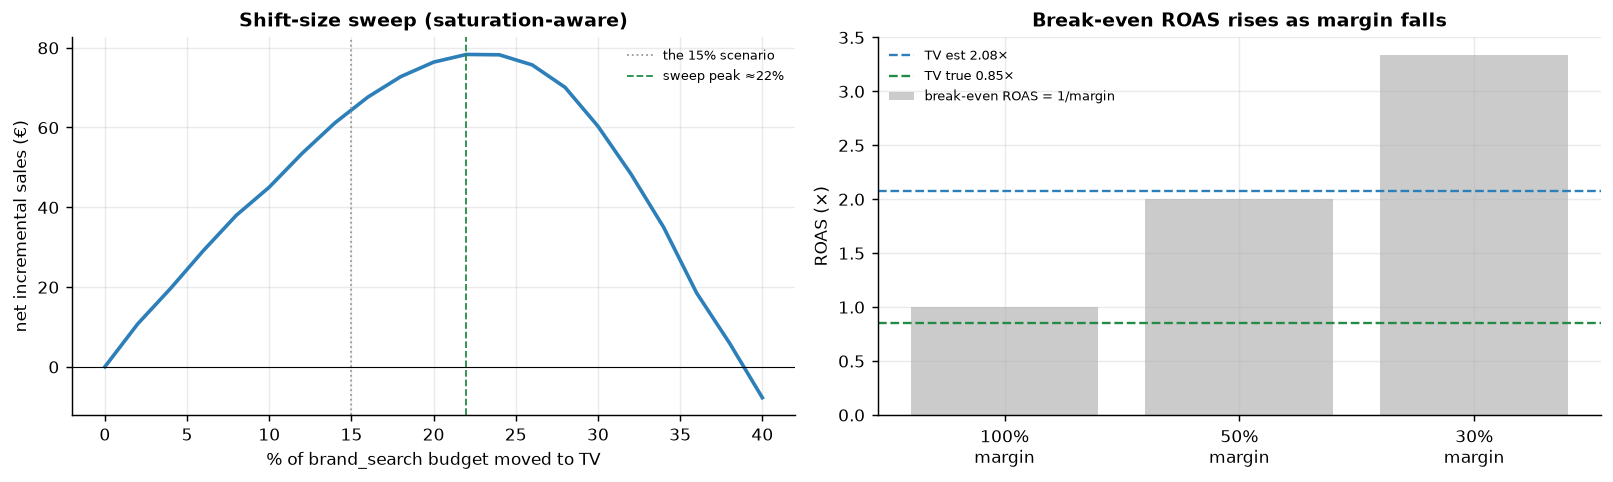

In [17]:
SHIFT = 0.15   # the single scenario — now shown inside a full shift-size sweep
n_wk = len(df)
# --- Saturation-aware marginal ROAS: fit the Michaelis-Menten response the MMM itself used to the
# fitted weekly (spend, contribution) points, so we can move budget ALONG the real saturating curve. ---
from scipy.optimize import curve_fit
def _mm(x, a, b): return a * x / (b + x)
def _contrib_fn(x, y):                       # -> (total_contribution(spend_array), mm_params or None)
    try:
        p, _ = curve_fit(_mm, x, y, p0=[max(y.sum()/len(y)*2, 1.0), max(np.median(x), 1.0)],
                         bounds=(0, np.inf), maxfev=20000)
        return (lambda s: _mm(s, *p).sum()), p
    except Exception:
        roas = y.sum() / x.sum()             # linear fallback: constant ROAS
        return (lambda s: float((roas * np.asarray(s)).sum())), None
cw_tv = cw.sel(channel="tv").values; cw_bs = cw.sel(channel="brand_search").values
tv_fn, p_tv = _contrib_fn(df["tv"].values, cw_tv)
bs_fn, p_bs = _contrib_fn(df["brand_search"].values, cw_bs)

# average vs marginal ROAS (per euro) at today's operating spend
avg_roas_tv = roi_tv.mean()
if p_tv is not None:
    a, b = p_tv; xbar = df["tv"].mean(); marg_roas_tv = a * b / (b + xbar) ** 2
else:
    marg_roas_tv = avg_roas_tv
print(f"TV ROAS — average {avg_roas_tv:.2f}× · marginal (the next euro, at today's spend) {marg_roas_tv:.2f}× "
      f"— marginal is lower because of saturation (diminishing returns).")

# --- Shift-size sweep: move x% of brand_search budget into TV, ALONG the fitted curves ---
shifts = np.linspace(0, 0.40, 21); tv0, bs0 = df["tv"].values, df["brand_search"].values
net_gain = np.array([tv_fn(tv0 + s*spend_bs/n_wk) - tv_fn(tv0)
                     - (bs_fn(bs0) - bs_fn(np.clip(bs0 - s*spend_bs/n_wk, 0, None))) for s in shifts])
best = int(np.nanargmax(net_gain)); best_shift = shifts[best]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(shifts*100, net_gain, color=plots.BLUE, lw=2)
ax[0].axvline(SHIFT*100, color=plots.GREY, ls=":", lw=1, label=f"the {SHIFT:.0%} scenario")
ax[0].axvline(best_shift*100, color=plots.GREEN, ls="--", lw=1, label=f"sweep peak ≈{best_shift:.0%}")
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xlabel("% of brand_search budget moved to TV")
ax[0].set_ylabel("net incremental sales (€)"); ax[0].set_title("Shift-size sweep (saturation-aware)")
ax[0].legend(frameon=False, fontsize=7)
margins = [1.00, 0.50, 0.30]
ax[1].bar([f"{int(m*100)}%\nmargin" for m in margins], [1/m for m in margins], color=plots.GREY, alpha=0.5, label="break-even ROAS = 1/margin")
ax[1].axhline(roi_tv.mean(), color=plots.BLUE, ls="--", lw=1.3, label=f"TV est {roi_tv.mean():.2f}×")
ax[1].axhline(true_tv/spend_tv, color=plots.GREEN, ls="--", lw=1.3, label=f"TV true {true_tv/spend_tv:.2f}×")
ax[1].set_ylabel("ROAS (×)"); ax[1].set_title("Break-even ROAS rises as margin falls"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()

p_gain = (roi_tv > roi_bs).mean()
delta_sat = float(net_gain[np.argmin(np.abs(shifts - SHIFT))])
tr_tv, tr_bs = true_tv/spend_tv, true_bs/spend_bs
print(f"\nShifting {SHIFT:.0%} of brand_search spend (€{SHIFT*spend_bs:,.0f}) to TV → +€{delta_sat:,.0f} net sales "
      f"over the {n_wk}-week planning window (saturation-aware); the sweep peaks near {best_shift:.0%}.")
print(f"P(TV ROAS > brand_search ROAS) = {p_gain:.2f} → " + ("reallocate toward TV" if p_gain > 0.8 else "lean toward TV, but test first"))
print(f"\nRanking vs levels — the watertight part:")
print(f"  TRUE ROAS: TV {tr_tv:.2f}× · brand_search {tr_bs:.2f}× (both BELOW 1×)  |  MMM says TV {roi_tv.mean():.2f}× · bs {roi_bs.mean():.2f}×")
print(f"  The MMM recovers the RANKING (TV ≫ brand_search) but overstates LEVELS ~{roi_tv.mean()/tr_tv:.1f}× for TV.")
print(f"  ROAS is revenue ÷ spend — it assumes 100% margin. At a realistic 30% margin the break-even is 1/0.30 ≈ {1/0.30:.1f}×,")
print(f"  which even TV's estimated {roi_tv.mean():.2f}× fails; and TV's TRUE ROAS {tr_tv:.2f}× is below break-even at ANY margin.")
print(f"  So: reallocate toward TV (the ranking is trustworthy), but 'is TV worth it in absolute €?' needs the geo")
print(f"  experiment (nb 07) — this MMM's absolute levels are not calibrated enough to answer it.")

# --- Decision quantity WITH uncertainty + recover-the-truth check (per posterior draw, not just the mean) ---
# The net_gain sweep above is saturation-aware but uses only MEAN weekly contributions. Carry the same 15%
# reallocation through EVERY posterior draw via each draw's channel ROAS (roi_tv/roi_bs, from tv_post/bs_post)
# — a first-order (average-ROAS) reallocation — to put an interval and P(Δ>0) on the decision quantity, then
# check it against the DGP truth already loaded in true_contrib (true_tv/true_bs).
A = SHIFT * spend_bs                                    # euros moved brand_search -> TV
delta_draws = A * (roi_tv - roi_bs)                     # per-draw Δsales (average-ROAS reallocation)
d_lo, d_hi = np.quantile(delta_draws, [0.05, 0.95])
p_help = float((delta_draws > 0).mean())
true_delta = A * (tr_tv - tr_bs)                        # DGP truth: same shift priced at TRUE channel ROAS
print(f"\nDecision quantity WITH uncertainty — shift {SHIFT:.0%} (€{A:,.0f})")
print("brand_search -> TV (per-draw, average-ROAS):")
print(f"  Δsales = €{delta_draws.mean():,.0f}  [90% €{d_lo:,.0f}, €{d_hi:,.0f}]  ·  P(Δ>0) = {p_help:.2f}")
print(f"  TRUE Δsales (from DGP true_contrib) = €{true_delta:,.0f}  ->  direction check: "
      + ("MATCH (both favour TV)" if np.sign(delta_draws.mean()) == np.sign(true_delta) else "MISMATCH"))

# The two figures cell 32 weighs, for the SAME shift — printed side by side so the prose can point here.
# NOTE ON UNITS: both figures are WINDOW TOTALS, not weekly rates. net_gain sums _mm(...) over all
# n_wk weeks, and A = SHIFT * spend_bs is 15% of the WHOLE-SERIES brand_search spend — the same A that
# prices true_delta below, which is (correctly) labelled per planning window.
print(f"\nTHE TWO Δsales FIGURES cell 32 weighs, same {SHIFT:.0%} shift (both over the {n_wk}-week window):")
print(f"  - saturation-aware (walks both channels DOWN their fitted curves)   : €{delta_sat:,.0f} per planning window  <- the honest planning number")
print(f"  - average-ROAS     (ignores saturation, carries the uncertainty band): €{delta_draws.mean():,.0f} per planning window [90% €{d_lo:,.0f}, €{d_hi:,.0f}], P(Δ>0)={p_help:.2f}")

# --- Price the geo experiment itself (value of information). What would acting on the DEFAULT
# MMM have cost? Its inverted ranking (brand_search >> TV) implies the MIRROR action: move 15% of
# the TV budget INTO brand_search. Price both policies at the TRUE channel ROAS from the DGP.
A_bad = SHIFT * spend_tv                       # euros the default MMM would have moved tv -> brand_search
delta_bad = A_bad * (tr_bs - tr_tv)            # < 0 by the planted truth: value destroyed per window
swing = true_delta - delta_bad                 # what the experiment's information was worth, per window
print(f"\nPricing the experiment (the notebook's punchline, in euros): acting on")
print(f"the DEFAULT MMM means shifting {SHIFT:.0%} of TV spend (€{A_bad:,.0f}) into")
print(f"brand_search -> Δsales = €{delta_bad:,.0f} per planning window (value DESTROYED);")
print(f"acting on the CALIBRATED MMM adds €{true_delta:,.0f}. The swing, €{swing:,.0f}")
print(f"per window — recurring every window — is a FLOOR on what the geo experiment")
print(f"that calibrated the prior was worth (it prices only this one {SHIFT:.0%}")
print(f"decision, nothing else the calibration de-risks). If the test costs less")
print(f"than a few windows of that, it pays for itself.")

**Which Δsales number goes to the CFO?** The block just above prints **two Δsales figures for the same 15% shift**, and they differ by roughly an order of magnitude *on purpose*. The **saturation-aware** figure walks both channels *down* their fitted response curves — at TV's current operating point the marginal curve is already nearly flat, so the honest planning number is small (in the committed FULL run ≈ +€61 **over the whole 156-week planning window** — these are window totals, not weekly rates; a FAST run prints an even smaller, noisier value that can dip slightly negative). The **average-ROAS** figure prices the same shift at each posterior draw's *average* ROAS — it ignores saturation entirely, so it lands far larger (≈ +€836 per planning window in the FULL run, ~14× the saturation-aware figure), and is kept only because it carries the uncertainty band: its printed P(Δ>0) is the **ranking probability in euro clothing** — by construction Δ>0 exactly when TV's ROAS beats brand_search's. **Quote the saturation-aware figure to the CFO; use the average-ROAS band as the direction check it is.**

### Giving the planning number its band

One loose end, flagged honestly: the saturation-aware sweep above was built by re-fitting a
Michaelis–Menten curve to the **posterior-mean** weekly contributions with `scipy.curve_fit` — a
plug-in convenience that throws the posterior away, which is why the saturation-aware planning number above
printed with no interval while the cruder average-ROAS number carried one. A notebook that preaches
posteriors should not quietly switch to point estimates for its decision-critical figure. The fix
costs almost nothing: repeat the same curve fit on **each posterior draw** of the calibrated MMM's
weekly contributions, push every draw through the same budget shift, and the sweep inherits a
genuine 90% credible band.

Saturation-aware Δsales at the 15% shift, per 156-week planning window: median €59 [90% €-13, €115] · P(Δ>0) = 0.90 (from 300 of 300 draws)
This is the CFO sentence completed: quote the saturation-aware median WITH its band, alongside the
ranking probability — the band separates conviction from hope.


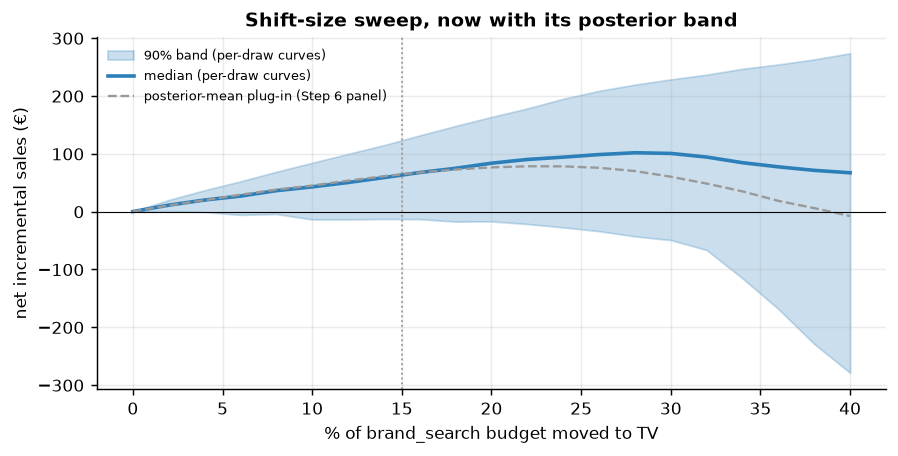

In [18]:
stk = mmm.compute_channel_contribution_original_scale().stack(sample=("chain", "draw"))
n_s = int(stk.sizes["sample"]); take = min(150 if FAST else 300, n_s)
sel = np.random.default_rng(SEED).choice(n_s, size=take, replace=False)
gain_draws = np.full((take, len(shifts)), np.nan)
for k, i in enumerate(sel):
    try:
        ptv, _ = curve_fit(_mm, tv0, stk.sel(channel="tv").isel(sample=int(i)).values,
                           p0=[max(cw_tv.max(), 1.0), max(np.median(tv0), 1.0)], bounds=(0, np.inf), maxfev=8000)
        pbs, _ = curve_fit(_mm, bs0, stk.sel(channel="brand_search").isel(sample=int(i)).values,
                           p0=[max(cw_bs.max(), 1.0), max(np.median(bs0), 1.0)], bounds=(0, np.inf), maxfev=8000)
    except Exception:
        continue                                   # a failed draw stays NaN and drops out of the quantiles
    for j, s in enumerate(shifts):
        gain_draws[k, j] = (_mm(tv0 + s * spend_bs / n_wk, *ptv).sum() - _mm(tv0, *ptv).sum()
                            - (_mm(bs0, *pbs).sum() - _mm(np.clip(bs0 - s * spend_bs / n_wk, 0, None), *pbs).sum()))

lo_g, med_g, hi_g = np.nanquantile(gain_draws, [0.05, 0.5, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.fill_between(shifts * 100, lo_g, hi_g, color=plots.BLUE, alpha=0.25, label="90% band (per-draw curves)")
ax.plot(shifts * 100, med_g, color=plots.BLUE, lw=2, label="median (per-draw curves)")
ax.plot(shifts * 100, net_gain, color=plots.GREY, lw=1.3, ls="--", label="posterior-mean plug-in (Step 6 panel)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(SHIFT * 100, color=plots.GREY, ls=":", lw=1)
ax.set_xlabel("% of brand_search budget moved to TV"); ax.set_ylabel("net incremental sales (€)")
ax.set_title("Shift-size sweep, now with its posterior band"); ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
j15 = int(np.argmin(np.abs(shifts - SHIFT)))
d15 = gain_draws[:, j15]; d15 = d15[~np.isnan(d15)]
p15 = float((d15 > 0).mean())
print(f"Saturation-aware Δsales at the {SHIFT:.0%} shift, per {n_wk}-week planning window: "
      f"median €{np.median(d15):,.0f} "
      f"[90% €{np.quantile(d15, .05):,.0f}, €{np.quantile(d15, .95):,.0f}] · P(Δ>0) = {p15:.2f} "
      f"(from {len(d15)} of {take} draws)")
print("This is the CFO sentence completed: quote the saturation-aware median WITH its band, alongside the")
print("ranking probability — the band separates conviction from hope"
      + (". NOTE (FAST run): short ranking-grade chains make this sizing readout noisy — the ranking is"
         "\nstable across modes, but SIZE the move from a FULL run." if FAST else "."))

### The one-paragraph decision

> **Recommendation: act on the ranking, pilot the shift, and let a geo test set the levels.** The
> calibrated MMM's channel **ranking** — TV above brand_search — is the trustworthy part of this
> analysis: it is direction-checked against the planted truth, and the posterior predictive check
> showed the competing default-prior reading buys no extra fit — the experiment, not the data, is
> what identified it. Its robustness is real but **bounded, and View 6 prints the bound**: the
> ranking holds only while the brand-search ceiling prior stays at or below the calibrated
> $\mu_{bs} = 0.3$, and flips at the very next grid point ($\mu_{bs} = 0.6$) — i.e. the geo test
> would have to have been wrong by **about twofold**, no more, to overturn the direction. Quote that
> twofold margin, not "any reasonable prior". *How much* to move is where honesty bites: judge the printed
> $P(\text{TV beats brand\_search})$ against the 0.8 action bar (in the committed FULL run it lands
> just short, at ≈0.78 — hence "pilot", not "reallocate"), and size the pilot from the
> **saturation-aware sweep with its band**, never from average ROAS — in the FULL run that sweep
> peaks at a roughly one-fifth shift, while a FAST run's short chains are ranking-grade only and
> should not size anything. The absolute euro **levels** are explicitly not decision-grade: the MMM
> overstates contributions several-fold even after calibration, and the *true* TV ROAS sits below
> break-even at any margin, so "is TV worth it at all?" belongs to the geo experiment (nb 07) —
> whose per-window value the swing computation above already floors in euros, recurring every
> planning cycle. Act on the ranking; pilot the shift; let the experiment set the levels.

In [19]:
import json
decision = {
    "true_contribution_eur": {"tv": round(true_tv), "brand_search": round(true_bs)},
    "mmm_default": {"tv": round(float(tv_def.mean())), "brand_search": round(float(bs_def.mean())),
                    "ranking_correct": bool(tv_def.mean() > bs_def.mean()),
                    "convergence": est.convergence_report(idata_def)["summary"]},
    "mmm_calibrated": {"tv": round(float(tv_post.mean())), "brand_search": round(float(bs_post.mean())),
                       "ranking_correct": bool(tv_post.mean() > bs_post.mean()),
                       "convergence": est.convergence_report(idata_cal)["summary"]},
    "ppc_share_in_90pct_band": {"default": round(covs["default"], 2), "calibrated": round(covs["calibrated"], 2)},
    "p_rank_correct_calibrated": round(float(p_gain), 2), "action_bar": 0.8,
    "prior_sweep": {"grid_mu_bs": MUS, "p_tv_beats_bs": [round(float(p), 2) for p in p_rank],
                    "flips_at_mu": (float(mus_flip.min()) if len(mus_flip) else None)},
    "chosen_shift_of_bs_budget": SHIFT,
    "delta_sales_saturation_aware_eur": {"median": round(float(np.median(d15))),
                                         "lo90": round(float(np.quantile(d15, .05))),
                                         "hi90": round(float(np.quantile(d15, .95))),
                                         "p_positive": round(p15, 2)},
    "delta_sales_avg_roas_eur": {"mean": round(float(delta_draws.mean())),
                                 "lo90": round(float(d_lo)), "hi90": round(float(d_hi))},
    "true_delta_sales_eur": round(float(true_delta)),
    "experiment_value_floor_eur_per_window": round(float(swing)),
    "verdict": "pilot shift toward TV (ranking trustworthy); geo test for absolute levels",
}
print(json.dumps(decision, indent=2))

{
  "true_contribution_eur": {
    "tv": 5263,
    "brand_search": 518
  },
  "mmm_default": {
    "tv": 10390,
    "brand_search": 36007,
    "ranking_correct": false,
    "convergence": "max r-hat 1.010 - min ESS 381 - divergences 14"
  },
  "mmm_calibrated": {
    "tv": 12820,
    "brand_search": 2262,
    "ranking_correct": true,
    "convergence": "max r-hat 1.010 - min ESS 376 - divergences 0"
  },
  "ppc_share_in_90pct_band": {
    "default": 0.89,
    "calibrated": 0.9
  },
  "p_rank_correct_calibrated": 0.78,
  "action_bar": 0.8,
  "prior_sweep": {
    "grid_mu_bs": [
      0.15,
      0.3,
      0.6,
      1.0,
      2.0
    ],
    "p_tv_beats_bs": [
      0.93,
      0.86,
      0.39,
      0.21,
      0.12
    ],
    "flips_at_mu": 0.6
  },
  "chosen_shift_of_bs_budget": 0.15,
  "delta_sales_saturation_aware_eur": {
    "median": 59,
    "lo90": -13,
    "hi90": 115,
    "p_positive": 0.9
  },
  "delta_sales_avg_roas_eur": {
    "mean": 836,
    "lo90": -799,
    "hi90": 46

## 7 · Caveats

- **Absolute contributions need calibration.** Even the calibrated MMM runs a few times too high in absolute euros,
  because channel spend rides the seasonal wave the model can't fully net out from a short series. **Trust
  the ranking and the ROI verdict, not the absolute euros** — and note it took an experiment-informed prior
  to get even the *ranking* right. This is the single most important thing to say about any MMM.
- **A DAG is necessary but not sufficient.** The correct backdoor control (seasonality) did not stop a
  flexibly-saturated, collinear channel from re-absorbing the confounder. Structural assumptions still need
  experimental calibration to be trustworthy.
- **Fixing the transform does not remove its uncertainty — it hides it.** Step 0's classical MMM
  grid-searches λ and κ and then reports OLS intervals *conditional* on them. Its profile-likelihood
  region showed those constants are barely identified at all, so that interval understates total
  uncertainty by a large factor (printed there) and can exclude the truth outright. If you inherit an
  MMM whose adstock and saturation were "set to industry standards", the intervals on its ROAS are
  decorative.
- **Adstock/saturation priors matter — a lot.** Carry-over (λ) and diminishing-returns (α, κ) are weakly
  identified from limited weekly data; here the saturation-ceiling prior *flipped the conclusion*. Use
  informative priors from experiments wherever you have them.
- **Correlated channels → wide, correlated ROI posteriors.** When spend moves with a confounder, the data
  can't fully separate them; the intervals will (honestly) show it.

---
## Book export

The book chapter built from this notebook (`book/chapters/mmm.tex`) does not retype a single
number. Every figure it prints — every euro amount, ROAS, coverage rate, table cell and plot —
is *emitted* below by `cmp.report` into `book/build/results/nb06.json`, from which `book/build.py`
generates `macros.tex`, the booktabs tables and the vector figures the chapter `\input`s. A number
that goes stale is impossible; a number that goes *missing* is a LaTeX compile error rather than a
silent hole. The cell re-renders its figures in book style and closes them, so the notebook above
is unchanged.


In [20]:
# ---------------------------------------------------------------- Book export (cmp.report)
# The book chapter (book/chapters/mmm.tex) never retypes a number: every figure it prints is
# emitted HERE, from this executed run, into book/build/results/nb06.json -> macros.tex (see
# src/cmp/report.py). A missing macro is a LaTeX compile error, never a silent hole. Figures are
# re-rendered in book style (vector PDF, no in-figure title — the caption does that work) and
# closed immediately, so this cell changes nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as R

def V(k, v, **kw):
    return R.value(f"nb06.{k}", v, **kw)

def _q(v, p):
    return float(np.quantile(np.asarray(v), p))

# ============================================================ the world and the planted truth
V("n_weeks", int(n_t), fmt="d")
V("seed", int(SEED), fmt="d")
V("true_tv", true_tv, unit="EUR", fmt=",.0f")
V("true_bs", true_bs, unit="EUR", fmt=",.0f")
V("true_ratio", true_tv / true_bs, fmt=".0f")
V("spend_tv", spend_tot["tv"], unit="EUR", fmt=",.0f")
V("spend_bs", spend_tot["brand_search"], unit="EUR", fmt=",.0f")
V("true_roas_tv", true_roas["tv"], fmt=".2f")
V("true_roas_bs", true_roas["brand_search"], fmt=".2f")
_corr_bs = float(df["brand_search"].corr(df["seasonality"]))
_corr_tv = float(df["tv"].corr(df["seasonality"]))
V("corr_bs_season", _corr_bs, fmt=".2f")
V("corr_tv_season", _corr_tv, fmt=".2f")
V("lmax", 8, fmt="d")

# ============================================================ Step 0 · the classical arm
V("cl_n_grid", int(len(GRID)), fmt=",d")
V("cl_lam_tv", LAM_HAT["tv"], fmt=".2f")
V("cl_lam_bs", LAM_HAT["brand_search"], fmt=".2f")
V("cl_kap_tv", KAP_HAT["tv"], unit="EUR", fmt=".0f")
V("cl_kap_bs", KAP_HAT["brand_search"], unit="EUR", fmt=".0f")
V("cl_rsq", float(hat.r2), fmt=".4f")
V("cl_maxlags", int(MAXLAGS), fmt="d")
V("cl_acf_one", ac1, fmt="+.2f")
V("cl_se_infl_tv", CLS["tv"]["se_infl"], fmt=".2f")
V("cl_se_infl_bs", CLS["brand_search"]["se_infl"], fmt=".2f")
for _c, _k in [("tv", "tv"), ("brand_search", "bs")]:
    V(f"cl_alpha_{_k}", CLS[_c]["alpha"], unit="EUR", fmt=".1f")
    V(f"cl_contrib_{_k}", CLS[_c]["contrib"], unit="EUR", fmt=",.0f")
    V(f"cl_contrib_{_k}_lo", CLS[_c]["contrib_ci"][0], unit="EUR", fmt=",.0f")
    V(f"cl_contrib_{_k}_hi", CLS[_c]["contrib_ci"][1], unit="EUR", fmt=",.0f")
    V(f"cl_roas_{_k}", CLS[_c]["roas"], fmt=".2f")
    V(f"cl_roas_{_k}_lo", CLS[_c]["roas_ci"][0], fmt=".2f")
    V(f"cl_roas_{_k}_hi", CLS[_c]["roas_ci"][1], fmt=".2f")
    V(f"cl_ratio_{_k}", CLS[_c]["contrib"] / true_contrib_tot[_c], fmt=".2f")
V("cl_ranking", "TV first" if rank_ok else "INVERTED")

# the profile region: what the fit genuinely cannot rule out
V("reg_n", int(len(REG)), fmt=",d")
V("reg_share", 100 * len(REG) / len(GRID), fmt=".0f")
V("reg_lam_tv_lo", float(REG.lam_tv.min()), fmt=".2f")
V("reg_lam_tv_hi", float(REG.lam_tv.max()), fmt=".2f")
V("reg_lam_bs_lo", float(REG.lam_bs.min()), fmt=".2f")
V("reg_lam_bs_hi", float(REG.lam_bs.max()), fmt=".2f")
V("reg_kap_tv_lo", float(REG.kap_tv.min()), unit="EUR", fmt=".0f")
V("reg_kap_tv_hi", float(REG.kap_tv.max()), unit="EUR", fmt=".0f")
V("reg_kap_bs_lo", float(REG.kap_bs.min()), unit="EUR", fmt=".0f")
V("reg_kap_bs_hi", float(REG.kap_bs.max()), unit="EUR", fmt=".0f")
V("env_lo", env_lo, fmt=".2f")
V("env_hi", env_hi, fmt=".2f")
V("env_width", env_w, fmt=".2f")
V("ci_lo", ci_lo, fmt=".2f")
V("ci_hi", ci_hi, fmt=".2f")
V("ci_width", ci_w, fmt=".2f")
V("env_over_ci", env_w / ci_w, fmt=".0f")
V("reg_rank_ok", 100 * reg_rank_ok, fmt=".0f")
V("reg_roas_bs_lo", float(REG.roas_bs.min()), fmt=".2f")
V("reg_roas_bs_hi", float(REG.roas_bs.max()), fmt=".2f")
V("reg_n_negative_bs", int((REG.c_bs < 0).sum()), fmt=",d")
V("cl_truth_in_ci", "inside" if ci_lo <= true_roas["tv"] <= ci_hi else "outside")
V("cl_truth_in_env", "inside" if env_lo <= true_roas["tv"] <= env_hi else "outside")

# the "industry standard transform" spreadsheet: same data, the transform simply asserted
ASSERT = pd.DataFrame(arows)
V("assert_rsq_lo", float(ASSERT["R²"].min()), fmt=".4f")
V("assert_rsq_hi", float(ASSERT["R²"].max()), fmt=".4f")
V("assert_roas_tv_lo", float(ASSERT["TV ROAS"].min()), fmt=".2f")
V("assert_roas_tv_hi", float(ASSERT["TV ROAS"].max()), fmt=".2f")
V("assert_n_inverted", int((ASSERT["ranking"] == "INVERTED").sum()), fmt="d")
V("assert_n", int(len(ASSERT)), fmt="d")

# ============================================================ §4 · the two Bayesian fits
_cv_d = est.convergence_report(idata_def)
_cv_c = est.convergence_report(idata_cal)
V("n_draws", int(DRAWS["draws"] * DRAWS["chains"]), fmt=",d")
V("n_chains", int(DRAWS["chains"]), fmt="d")
V("target_accept", NUTS["target_accept"], fmt=".2f")
V("def_rhat", _cv_d["max_rhat"], fmt=".3f")
V("def_ess", _cv_d["min_ess_bulk"], fmt=",.0f")
V("def_div", int(_cv_d["n_divergences"] or 0), fmt="d")
V("cal_rhat", _cv_c["max_rhat"], fmt=".3f")
V("cal_ess", _cv_c["min_ess_bulk"], fmt=",.0f")
V("cal_div", int(_cv_c["n_divergences"] or 0), fmt="d")

V("def_tv", float(tv_def.mean()), unit="EUR", fmt=",.0f")
V("def_bs", float(bs_def.mean()), unit="EUR", fmt=",.0f")
V("def_tv_lo", _q(tv_def, .05), unit="EUR", fmt=",.0f")
V("def_tv_hi", _q(tv_def, .95), unit="EUR", fmt=",.0f")
V("def_bs_lo", _q(bs_def, .05), unit="EUR", fmt=",.0f")
V("def_bs_hi", _q(bs_def, .95), unit="EUR", fmt=",.0f")
V("def_bs_over_true", float(bs_def.mean()) / true_bs, fmt=".0f")
V("def_ranking", "TV first" if tv_def.mean() > bs_def.mean() else "INVERTED")
V("cal_tv", float(tv_post.mean()), unit="EUR", fmt=",.0f")
V("cal_bs", float(bs_post.mean()), unit="EUR", fmt=",.0f")
V("cal_tv_lo", _q(tv_post, .05), unit="EUR", fmt=",.0f")
V("cal_tv_hi", _q(tv_post, .95), unit="EUR", fmt=",.0f")
V("cal_bs_lo", _q(bs_post, .05), unit="EUR", fmt=",.0f")
V("cal_bs_hi", _q(bs_post, .95), unit="EUR", fmt=",.0f")
V("cal_ranking", "TV first" if tv_post.mean() > bs_post.mean() else "INVERTED")
V("cal_tv_over_true", float(tv_post.mean()) / true_tv, fmt=".1f")
V("cal_bs_over_true", float(bs_post.mean()) / true_bs, fmt=".1f")

V("def_roas_tv", float(roas_def_tv.mean()), fmt=".2f")
V("def_roas_bs", float(roas_def_bs.mean()), fmt=".2f")
V("cal_roas_tv", float(roi_tv.mean()), fmt=".2f")
V("cal_roas_tv_lo", _q(roi_tv, .05), fmt=".2f")
V("cal_roas_tv_hi", _q(roi_tv, .95), fmt=".2f")
V("cal_roas_bs", float(roi_bs.mean()), fmt=".2f")
V("cal_roas_bs_lo", _q(roi_bs, .05), fmt=".2f")
V("cal_roas_bs_hi", _q(roi_bs, .95), fmt=".2f")
V("p_roas_tv_gt_one", float((roi_tv > 1).mean()), fmt=".2f")
V("p_roas_bs_gt_one", float((roi_bs > 1).mean()), fmt=".2f")
V("cal_roas_tv_over_true", float(roi_tv.mean()) / true_roas["tv"], fmt=".1f")

# the naive OLS ladder (the confounding correction)
V("naive_bs", float(naive_bs), unit="EUR", fmt=",.0f")
V("naive_tv", float(naive_tv), unit="EUR", fmt=",.0f")
V("adj_bs", float(adj_bs), unit="EUR", fmt=",.0f")
V("adj_tv", float(adj_tv), unit="EUR", fmt=",.0f")

# the level decomposition: where the stolen credit is paid for
_ic_d = idata_def.posterior["intercept"].values.ravel() * y_max
_ic_c = idata_cal.posterior["intercept"].values.ravel() * y_max
V("def_baseline", float(_ic_d.mean()), unit="EUR", fmt=",.0f")
V("cal_baseline", float(_ic_c.mean()), unit="EUR", fmt=",.0f")
V("true_baseline", 100.0, unit="EUR", fmt=".0f")
V("def_ceiling_bs", float(ceil_d), unit="EUR", fmt=".1f")
V("cal_ceiling_bs", float(ceil_c), unit="EUR", fmt=".1f")
V("true_ceiling_bs", 8.0, unit="EUR", fmt=".0f")
V("def_ceiling_bs_over_true", float(ceil_d) / 8.0, fmt=".0f")
V("cal_ceiling_bs_over_true", float(ceil_c) / 8.0, fmt=".1f")

# ============================================================ §5 · diagnostics and validation
V("ppc_cov_def", 100 * covs["default"], fmt=".0f")
V("ppc_cov_cal", 100 * covs["calibrated"], fmt=".0f")
V("ppc_rmse_def", rmses["default"], fmt=".1f")
V("ppc_rmse_cal", rmses["calibrated"], fmt=".1f")
V("dgp_sigma", 4, fmt="d")

# prior sweep
V("sweep_mu_cal", 0.3, fmt=".1f")
V("sweep_mu_default", 2.0, fmt=".1f")
V("sweep_n_grid", int(len(MUS)), fmt="d")
V("sweep_p_lo", float(p_rank[0]), fmt=".2f")
V("sweep_p_hi", float(p_rank[-1]), fmt=".2f")
V("sweep_hold_to", float(mus_ok.max()) if len(mus_ok) else float("nan"), fmt=".2f")
V("sweep_flip_at", float(mus_flip.min()) if len(mus_flip) else float("nan"), fmt=".1f")
V("sweep_factor", (float(mus_flip.min()) / 0.3) if len(mus_flip) else float("nan"), fmt=".0f")
V("sweep_n_flipped", int((p_rank <= 0.5).sum()), fmt="d")

# ============================================================ §6 · the euro decision
V("shift_pct", 100 * SHIFT, fmt=".0f")
V("shift_eur", float(A), unit="EUR", fmt=",.0f")
V("p_tv_first", float(p_gain), fmt=".2f")
V("action_bar", 0.8, fmt=".1f")
V("best_shift", 100 * float(best_shift), fmt=".0f")
V("avg_roas_tv", float(avg_roas_tv), fmt=".2f")
V("marg_roas_tv", float(marg_roas_tv), fmt=".2f")
_xbar_bs = float(df["brand_search"].mean())
_marg_bs = float(p_bs[0] * p_bs[1] / (p_bs[1] + _xbar_bs) ** 2) if p_bs is not None else float("nan")
V("marg_roas_bs", _marg_bs, fmt=".2f")
V("sat_delta", float(np.median(d15)), unit="EUR", fmt=",.0f")
V("sat_delta_lo", _q(d15, .05), unit="EUR", fmt=",.0f")
V("sat_delta_hi", _q(d15, .95), unit="EUR", fmt=",.0f")
V("sat_p_positive", float(p15), fmt=".2f")
V("sat_delta_plugin", float(delta_sat), unit="EUR", fmt=",.0f")
V("avg_delta", float(delta_draws.mean()), unit="EUR", fmt=",.0f")
V("avg_delta_lo", float(d_lo), unit="EUR", fmt=",.0f")
V("avg_delta_hi", float(d_hi), unit="EUR", fmt=",.0f")
V("avg_p_positive", float(p_help), fmt=".2f")
V("avg_over_sat", abs(float(delta_draws.mean()) / float(np.median(d15))), fmt=".0f")
V("true_delta", float(true_delta), unit="EUR", fmt=",.0f")
V("mirror_shift_eur", float(A_bad), unit="EUR", fmt=",.0f")
V("mirror_delta", float(delta_bad), unit="EUR", fmt=",.0f")
V("experiment_swing", float(swing), unit="EUR", fmt=",.0f")
V("breakeven_thirty", 1 / 0.30, fmt=".1f")
V("margin_thirty", 30, fmt="d")

# ============================================================ tables
R.table(pd.DataFrame([
    {"Estimator": "planted truth", "TV (EUR)": f"{true_tv:,.0f}",
     "brand search (EUR)": f"{true_bs:,.0f}", "Ranking": "TV first"},
    {"Estimator": "naive OLS (no season)", "TV (EUR)": f"{naive_tv:,.0f}",
     "brand search (EUR)": f"{naive_bs:,.0f}",
     "Ranking": "TV first" if naive_tv > naive_bs else "INVERTED"},
    {"Estimator": "OLS + season (linear)", "TV (EUR)": f"{adj_tv:,.0f}",
     "brand search (EUR)": f"{adj_bs:,.0f}",
     "Ranking": "TV first" if adj_tv > adj_bs else "INVERTED"},
    {"Estimator": "classical MMM (profiled)",
     "TV (EUR)": f"{CLS['tv']['contrib']:,.0f} [{CLS['tv']['contrib_ci'][0]:,.0f}, "
                 f"{CLS['tv']['contrib_ci'][1]:,.0f}]",
     "brand search (EUR)": f"{CLS['brand_search']['contrib']:,.0f} "
                           f"[{CLS['brand_search']['contrib_ci'][0]:,.0f}, "
                           f"{CLS['brand_search']['contrib_ci'][1]:,.0f}]",
     "Ranking": "TV first" if rank_ok else "INVERTED"},
    {"Estimator": "Bayesian MMM, default priors",
     "TV (EUR)": f"{tv_def.mean():,.0f} [{_q(tv_def,.05):,.0f}, {_q(tv_def,.95):,.0f}]",
     "brand search (EUR)": f"{bs_def.mean():,.0f} [{_q(bs_def,.05):,.0f}, {_q(bs_def,.95):,.0f}]",
     "Ranking": "TV first" if tv_def.mean() > bs_def.mean() else "INVERTED"},
    {"Estimator": "Bayesian MMM, calibrated",
     "TV (EUR)": f"{tv_post.mean():,.0f} [{_q(tv_post,.05):,.0f}, {_q(tv_post,.95):,.0f}]",
     "brand search (EUR)": f"{bs_post.mean():,.0f} [{_q(bs_post,.05):,.0f}, {_q(bs_post,.95):,.0f}]",
     "Ranking": "TV first" if tv_post.mean() > bs_post.mean() else "INVERTED"},
]), "nb06.compare", align="lrrc",
    caption=(f"Same estimand, same DAG, five estimators: total incremental sales over the "
             f"{n_t}-week window (EUR; mean and 90\\,\\% interval where one exists). The "
             f"default-prior Bayesian MMM does not merely mis-price brand search --- it ranks it "
             f"ABOVE television, crediting it {bs_def.mean():,.0f} against a planted "
             f"{true_bs:,.0f}. The experiment-calibrated prior restores the ranking. Read the last "
             f"column first: it is the one a budget is set from."))

R.table(pd.DataFrame([
    {"Estimator": "planted truth", "TV ROAS": f"{true_roas['tv']:.2f}",
     "brand search ROAS": f"{true_roas['brand_search']:.2f}"},
    {"Estimator": "classical MMM (profiled)",
     "TV ROAS": f"{CLS['tv']['roas']:.2f} [{CLS['tv']['roas_ci'][0]:.2f}, "
                f"{CLS['tv']['roas_ci'][1]:.2f}]",
     "brand search ROAS": f"{CLS['brand_search']['roas']:.2f} "
                          f"[{CLS['brand_search']['roas_ci'][0]:.2f}, "
                          f"{CLS['brand_search']['roas_ci'][1]:.2f}]"},
    {"Estimator": "the transform envelope", "TV ROAS": f"[{env_lo:.2f}, {env_hi:.2f}]",
     "brand search ROAS": f"[{float(REG.roas_bs.min()):.2f}, {float(REG.roas_bs.max()):.2f}]"},
    {"Estimator": "Bayesian MMM, default priors",
     "TV ROAS": f"{roas_def_tv.mean():.2f} [{_q(roas_def_tv,.05):.2f}, {_q(roas_def_tv,.95):.2f}]",
     "brand search ROAS": f"{roas_def_bs.mean():.2f} [{_q(roas_def_bs,.05):.2f}, "
                          f"{_q(roas_def_bs,.95):.2f}]"},
    {"Estimator": "Bayesian MMM, calibrated",
     "TV ROAS": f"{roi_tv.mean():.2f} [{_q(roi_tv,.05):.2f}, {_q(roi_tv,.95):.2f}]",
     "brand search ROAS": f"{roi_bs.mean():.2f} [{_q(roi_bs,.05):.2f}, {_q(roi_bs,.95):.2f}]"},
]), "nb06.roas", align="lrr",
    caption=(f"Return on ad spend --- incremental revenue per euro spent, with its 90\\,\\% "
             f"interval. Two readings. First, every arm overstates the LEVELS: the true TV ROAS is "
             f"{true_roas['tv']:.2f}, below break-even at any margin, and no estimator here says "
             f"so. Second, the classical interval is narrow because it CONDITIONS on the "
             f"grid-searched transform. Row three replaces it with the envelope of every "
             f"$(\\lambda, \\kappa)$ the same fit cannot rule out, and it widens by "
             f"{env_w / ci_w:.0f}$\\times$. Rankings survive; levels do not."))

R.table(ASSERT.rename(columns={"R²": "R2", "λ (both)": "lambda (both)",
                               "κ (× mean spend)": "kappa (x mean spend)"}),
        "nb06.transform", align="rrrrrc",
        caption=(f"``We use industry-standard values.'' Same data, same control, the adstock and "
                 f"saturation constants simply ASSERTED rather than estimated. The fit is "
                 f"indistinguishable across all {len(ASSERT)} settings --- R2 spans only "
                 f"{float(ASSERT['R²'].min()):.4f} to {float(ASSERT['R²'].max()):.4f} --- while "
                 f"the implied TV ROAS spans {float(ASSERT['TV ROAS'].min()):.2f} to "
                 f"{float(ASSERT['TV ROAS'].max()):.2f} and "
                 f"{int((ASSERT['ranking'] == 'INVERTED').sum())} of {len(ASSERT)} settings invert "
                 f"the channel ranking outright. The choice, not the data, is setting the answer."))

R.table(pd.DataFrame(rows), "nb06.recovery", align="llrll",
        caption=(f"Parameter recovery against the planted truth: posterior mean [90\\,\\% "
                 f"interval], mapped back from the sampler's scaled units into euros. The default "
                 f"fit's damage is CONCENTRATED --- brand search's saturation ceiling inflates to "
                 f"{ceil_d:.1f} against a planted 8.0, and the baseline is dragged to "
                 f"{_ic_d.mean():,.0f} against a planted 100 to pay for the stolen credit. The "
                 f"experiment-calibrated prior moves that one number and leaves the rest to the "
                 f"data. Note what calibration does NOT fix: TV's own curve parameters stay wide "
                 f"in both fits, which is why this chapter trusts the ranking and never the "
                 f"levels."))

R.table(pd.DataFrame([
    {"prior mean mu_bs": f"{m:g}", "TV contribution (EUR)": f"{sweep[m][0].mean():,.0f}",
     "brand search (EUR)": f"{sweep[m][1].mean():,.0f}",
     "P(TV > brand search)": f"{(sweep[m][0] > sweep[m][1]).mean():.2f}",
     "Ranking": "TV first" if (sweep[m][0] > sweep[m][1]).mean() > 0.5 else "INVERTED"}
    for m in MUS]), "nb06.sweep", align="rrrrc",
    caption=("The skeptic's question, answered with a number rather than a shrug: how strong does "
             "the experiment-informed prior have to be? The channel ranking holds only while the "
             f"prior mean on brand search's ceiling stays at or below "
             f"{float(mus_ok.max()) if len(mus_ok) else float('nan'):g}, and it flips at the very "
             f"next grid point, {float(mus_flip.min()) if len(mus_flip) else float('nan'):g} --- "
             f"{int((p_rank <= 0.5).sum())} of {len(MUS)} grid points invert. The honest "
             "robustness claim is therefore ABOUT TWOFOLD in the prior mean, not ``any reasonable "
             "prior''. The 0.3 and 2.0 rows are the two headline fits; the other three are "
             "ranking-grade refits."))

# ============================================================ figures (book style)
with mpl.rc_context(R.book_style()):
    # --- (1) the confounding, made visible ------------------------------------------------
    f, a = plt.subplots(1, 2, figsize=(11.4, 3.6))
    a[0].plot(df["date_week"], df["tv"], color=plots.BLUE, lw=1.2,
              label=f"TV spend (corr. with season {_corr_tv:.2f})")
    a[0].plot(df["date_week"], df["brand_search"], color=plots.ORANGE, lw=1.2,
              label=f"brand-search spend (corr. {_corr_bs:.2f})")
    a[0].plot(df["date_week"], 25 + 11 * df["seasonality"], color="k", ls="--", lw=1.2,
              label="the seasonal wave (scaled)")
    a[0].set_ylabel("weekly spend (€)"); a[0].set_xlabel("week")
    a[0].legend(frameon=False, fontsize=8)
    a[1].plot(df["date_week"], true_contrib["tv"], color=plots.BLUE, lw=1.4,
              label="TV → sales (true)")
    a[1].plot(df["date_week"], 35 * df["seasonality"], color=plots.GREY, lw=1.4, ls="--",
              label="season → sales")
    a[1].plot(df["date_week"], true_contrib["brand_search"], color=plots.ORANGE, lw=1.6,
              label="brand search → sales (true)")
    a[1].axhline(0, color="k", lw=0.6)
    a[1].set_ylabel("weekly sales moved (€)"); a[1].set_xlabel("week")
    a[1].legend(frameon=False, fontsize=8)
    f.autofmt_xdate()
    f.tight_layout()
    R.figure(f, "nb06.confound", caption=(
        f"The confound, before any model sees the data. LEFT: brand-search spend is built from the "
        f"same seasonal index that lifts sales, so it tracks the wave at a correlation of "
        f"{_corr_bs:.2f}, against television's {_corr_tv:.2f}. Whatever the season does to sales "
        f"will look, to a model, like brand search doing it. RIGHT: what actually moves sales each "
        f"week. Television's contribution is large, the seasonal swing is larger still, and brand "
        f"search's true contribution is the near-flat line at the bottom --- {true_bs:,.0f} "
        f"against television's {true_tv:,.0f} over the window. An attribution method must hand the "
        f"wave back to the season."))
    plt.close(f)

    # --- (2) the two transforms ------------------------------------------------------------
    f, a = plt.subplots(1, 2, figsize=(11.0, 3.3))
    _ell = np.arange(8)
    for _lam, _col in [(0.2, plots.ORANGE), (0.4, plots.BLUE), (0.8, plots.GREY)]:
        a[0].plot(_ell, _lam ** _ell, "o-", ms=4, lw=1.4, color=_col, label=f"λ = {_lam}")
    a[0].set_xlabel("weeks after the ad ran"); a[0].set_ylabel("share of week-0 push remaining")
    a[0].legend(frameon=False, fontsize=9)
    _ag = np.linspace(0, 160, 200)
    for (_al, _ka), _col, _lab in [((60, 50), plots.BLUE, "TV: α = 60, κ = 50"),
                                   ((8, 40), plots.ORANGE, "brand search: α = 8, κ = 40")]:
        a[1].plot(_ag, _al * _ag / (_ka + _ag), color=_col, lw=2, label=_lab)
        a[1].axhline(_al, color=_col, ls=":", lw=0.9)
        a[1].plot([_ka], [_al / 2], "o", color=_col, ms=6)
    a[1].set_xlabel("adstocked spend"); a[1].set_ylabel("incremental sales / week")
    a[1].legend(frameon=False, fontsize=9, loc="center right")
    f.tight_layout()
    R.figure(f, "nb06.curves", caption=(
        "The two transforms that make a media mix model non-linear, drawn at the values planted in "
        "the simulator. LEFT, geometric adstock: a euro of spend still exerts $\\lambda^{\\ell}$ "
        "of its original push $\\ell$ weeks later, so $\\lambda = 0.2$ is a one-week echo while "
        "$\\lambda = 0.8$ is still audible two months out. RIGHT, Michaelis--Menten saturation: "
        "the response climbs toward a ceiling $\\alpha$ --- the most the channel could ever add in "
        "a week --- and passes half of it at the half-saturation spend $\\kappa$ (the dot). The "
        "SLOPE of that curve, not its average, is what the next euro of budget buys, and the gap "
        "between the two is the subject of this chapter."))
    plt.close(f)

    # --- (3) the classical profile region ---------------------------------------------------
    f, a = plt.subplots(1, 2, figsize=(11.8, 3.9))
    a[0].scatter(OUT.roas_tv, OUT.r2, s=4, alpha=0.18, color=plots.GREY,
                 label="ruled out by the fit")
    a[0].scatter(REG.roas_tv, REG.r2, s=5, alpha=0.30, color=plots.BLUE,
                 label="inside the 90 % profile region")
    a[0].axvspan(ci_lo, ci_hi, color=plots.ORANGE, alpha=0.45, zorder=3,
                 label="the reported 90 % CI")
    a[0].axvline(true_roas["tv"], color=plots.GREEN, lw=1.8, ls="--", label="true TV ROAS")
    a[0].plot([CLS["tv"]["roas"]], [hat.r2], "*", color="k", ms=13, zorder=4,
              label="the profiled fit")
    a[0].set_xlim(0, min(float(REG.roas_tv.max()) * 1.15, 5))
    a[0].set_xlabel("implied TV ROAS (×)"); a[0].set_ylabel("R² of the fit")
    a[0].legend(frameon=False, fontsize=7.5, loc="lower right")
    a[1].scatter(OUT.c_tv, OUT.c_bs, s=4, alpha=0.18, color=plots.GREY)
    a[1].scatter(REG.c_tv, REG.c_bs, s=5, alpha=0.30, color=plots.BLUE)
    _xl = float(np.percentile(REG.c_tv, 99.5)) * 1.1
    _yl = max(float(np.percentile(REG.c_bs, 99.5)), true_bs) * 1.35
    a[1].plot([0, _xl], [0, _xl], color="k", lw=1.0, ls=":")
    a[1].plot([true_tv], [true_bs], "*", color=plots.GREEN, ms=17, zorder=5)
    a[1].plot([CLS["tv"]["contrib"]], [CLS["brand_search"]["contrib"]], "*", color="k", ms=13,
              zorder=5)
    a[1].annotate("planted truth", xy=(true_tv, true_bs), xytext=(9, -15),
                  textcoords="offset points", fontsize=8, color=plots.GREEN, fontweight="bold",
                  zorder=6)
    a[1].annotate("the profiled fit", xy=(CLS["tv"]["contrib"], CLS["brand_search"]["contrib"]),
                  xytext=(7, 11), textcoords="offset points", fontsize=8, color="k", zorder=6)
    a[1].set_xlim(0, _xl); a[1].set_ylim(-0.18 * _yl, _yl)
    a[1].axhline(0, color="k", lw=0.6)
    a[1].set_xlabel("TV contribution (€)"); a[1].set_ylabel("brand-search contribution (€)")
    f.tight_layout()
    R.figure(f, "nb06.profile", caption=(
        f"Every dot is one $(\\lambda, \\kappa)$ setting --- a complete, defensible media mix "
        f"model, fitted by ordinary least squares with the correct control. LEFT: the fit barely "
        f"separates them. R2 varies in the fourth decimal across settings whose implied TV ROAS "
        f"differ several-fold, and {100 * len(REG) / len(GRID):.0f}\\,\\% of the searched grid "
        f"survives inside the 90\\,\\% profile-likelihood region (blue). Against that cloud, the "
        f"interval the classical model actually REPORTS (orange) is a sliver: "
        f"{env_w / ci_w:.0f}$\\times$ narrower than the envelope of transforms the same fit cannot "
        f"rule out. That is not bad arithmetic; it is a correct answer to the question ``given "
        f"that $\\lambda$ and $\\kappa$ are exactly these, how precise is the ceiling?'' --- and "
        f"nobody knows that they are. RIGHT: the same region in decision space. Above the dotted "
        f"tie line the channel ranking is inverted."))
    plt.close(f)

    # --- (4) the PPC that cannot save you ----------------------------------------------------
    f, a = plt.subplots(1, 3, figsize=(13.6, 3.6))
    for _ax, _m in zip(a[:2], [mmm_default, mmm]):
        _mu, _lo, _hi, _cov, _rm = ppc_band(_m)
        _ax.fill_between(df["date_week"], _lo, _hi, color=plots.BLUE, alpha=0.25,
                         label="replicates, 5–95 %")
        _ax.plot(df["date_week"], _mu, color=plots.BLUE, lw=1.0, label="replicate mean")
        _ax.plot(df["date_week"], y.values, color="k", lw=1.0, label="observed sales")
        _ax.set_xlabel("week"); _ax.set_ylabel("weekly sales (€)")
        _ax.legend(frameon=False, fontsize=8)
    for _idt, _col, _lab in [(idata_def, plots.GREY, "default priors"),
                             (idata_cal, plots.BLUE, "calibrated priors")]:
        a[2].scatter(_idt.posterior["saturation_alpha"].sel(channel="brand_search").values.ravel(),
                     _idt.posterior["gamma_control"].isel(control=0).values.ravel(),
                     s=5, alpha=0.3, color=_col, label=_lab)
    a[2].plot([8 / y_max], [35 / y_max], "*", color=plots.GREEN, ms=15, label="truth (scaled)")
    a[2].set_xlabel("brand-search ceiling α (scaled)"); a[2].set_ylabel("season coefficient γ")
    a[2].legend(frameon=False, fontsize=8)
    f.autofmt_xdate()
    f.tight_layout()
    R.figure(f, "nb06.ppc", caption=(
        f"The posterior predictive check that cannot save you. LEFT and CENTRE: the default-prior "
        f"fit (which credits brand search {bs_def.mean():,.0f} against a planted {true_bs:,.0f}) "
        f"and the calibrated fit (which credits it {bs_post.mean():,.0f}) reproduce the SAME "
        f"observed series near-identically --- {100 * covs['default']:.0f}\\,\\% against "
        f"{100 * covs['calibrated']:.0f}\\,\\% of weeks inside the 5--95\\,\\% replicate band, and "
        f"a replicate-mean RMSE of {rmses['default']:.1f} against {rmses['calibrated']:.1f} euros "
        f"per week. Two decompositions an order of magnitude apart on brand search are equally "
        f"good fits to the same series. The likelihood cannot tell them apart, so no amount of "
        f"model criticism will. RIGHT: what the experiment-informed prior did. It did not overrule "
        f"the data --- it SELECTED among answers the data could not rank."))
    plt.close(f)

    # --- (5) the correction, and the calibrated ROAS ------------------------------------------
    f, a = plt.subplots(1, 2, figsize=(11.4, 3.8))
    _x = np.arange(2); _w = 0.16
    for _i, (_lab, _vals, _col) in enumerate([
            ("naive OLS", [naive_tv, naive_bs], plots.ORANGE),
            ("OLS + season", [adj_tv, adj_bs], plots.GOLD),
            ("MMM, default priors", [tv_def.mean(), bs_def.mean()], plots.GREY),
            ("MMM, calibrated", [tv_post.mean(), bs_post.mean()], plots.BLUE),
            ("truth", [true_tv, true_bs], plots.GREEN)]):
        a[0].bar(_x + (_i - 2) * _w, _vals, _w, color=_col, alpha=0.85, label=_lab)
    a[0].set_xticks(_x); a[0].set_xticklabels(["TV", "brand search"])
    a[0].legend(frameon=False, fontsize=8, ncol=2)
    a[0].set_ylabel("incremental sales, window (€)")
    plots.forest_plot(a[1], ["TV", "brand search"], [roi_tv.mean(), roi_bs.mean()],
                      [_q(roi_tv, .05), _q(roi_bs, .05)], [_q(roi_tv, .95), _q(roi_bs, .95)],
                      ref=1.0, xlabel="ROAS (× spend, log scale)", logx=True,
                      annot=[f"P(ROAS>1) = {(roi_tv > 1).mean():.0%}",
                             f"P(ROAS>1) = {(roi_bs > 1).mean():.0%}"])
    import matplotlib.ticker as _mt
    a[1].xaxis.set_major_locator(_mt.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    a[1].xaxis.set_major_formatter(_mt.FormatStrFormatter("%g"))
    a[1].xaxis.set_minor_locator(_mt.NullLocator())
    f.tight_layout()
    R.figure(f, "nb06.correction", caption=(
        f"LEFT: five readings of the same {n_t} weeks. Naive least squares over-credits brand "
        f"search; adding a LINEAR seasonality control collapses that credit toward the small "
        f"truth; and then the default-prior media mix model, with the correct control still in it, "
        f"INVERTS the ranking and credits brand search above television. The calibrated fit "
        f"restores it. A correct backdoor adjustment was necessary and was not sufficient. RIGHT: "
        f"the calibrated ROAS with its 90\\,\\% credible interval. Television clears break-even on "
        f"the mean but its interval dips below it; brand search sits below break-even outright. "
        f"The LEVELS are still not to be trusted --- the true TV ROAS is {true_roas['tv']:.2f}, "
        f"below break-even at any margin, and the calibrated fit says {roi_tv.mean():.2f}."))
    plt.close(f)

    # --- (6) the prior sweep --------------------------------------------------------------
    f, a = plt.subplots(1, 2, figsize=(11.4, 3.6))
    a[0].plot(mus, tv_sw, "o-", color=plots.BLUE, lw=1.6, label="TV contribution")
    a[0].plot(mus, bs_sw, "o-", color=plots.ORANGE, lw=1.6, label="brand-search contribution")
    a[0].axhline(true_tv, color=plots.BLUE, ls=":", lw=1)
    a[0].axhline(true_bs, color=plots.ORANGE, ls=":", lw=1)
    a[0].axvline(0.3, color=plots.GREEN, ls="--", lw=1.1, label="geo-experiment prior (0.3)")
    a[0].axvline(2.0, color=plots.GREY, ls="--", lw=1.1, label="library default (2.0)")
    a[0].set_xscale("log"); a[0].set_xticks(mus); a[0].set_xticklabels([str(m) for m in MUS])
    a[0].xaxis.set_minor_formatter(plt.NullFormatter())
    a[0].set_xlabel("prior mean μ on the brand-search ceiling (scaled)")
    a[0].set_ylabel("incremental sales (€)")
    a[0].legend(frameon=False, fontsize=7.5)
    a[1].plot(mus, p_rank, "o-", color=plots.BLUE, lw=1.8)
    a[1].axhline(0.5, color="k", ls=":", lw=1)
    a[1].axhline(0.8, color=plots.GREEN, ls=":", lw=1)
    a[1].text(mus[0], 0.53, "below: the ranking flips", fontsize=8, color="#555555")
    a[1].text(mus[0], 0.83, "0.8 action bar", fontsize=8, color=plots.GREEN)
    a[1].axvline(0.3, color=plots.GREEN, ls="--", lw=1.1)
    a[1].set_xscale("log"); a[1].set_xticks(mus); a[1].set_xticklabels([str(m) for m in MUS])
    a[1].xaxis.set_minor_formatter(plt.NullFormatter())
    a[1].set_ylim(-0.02, 1.05)
    a[1].set_xlabel("prior mean μ on the brand-search ceiling (scaled)")
    a[1].set_ylabel("P(TV contribution > brand search)")
    f.tight_layout()
    R.figure(f, "nb06.sweepfig", caption=(
        f"``Didn't you just pick the prior that gives the answer you wanted?'' --- answered by "
        f"refitting across it. LEFT: loosening the prior on brand search's ceiling slides its "
        f"estimated contribution smoothly away from its dotted truth line and back up toward the "
        f"flat likelihood's preferred answer, with the data pushing back only weakly anywhere "
        f"along the way. That gentleness IS the finding: the likelihood barely resists, so the "
        f"prior's strength maps almost one-for-one onto the conclusion. RIGHT: the ranking "
        f"probability. It stays above 0.5 only for $\\mu \\le "
        f"{float(mus_ok.max()) if len(mus_ok) else float('nan'):g}$ and is already flipped at the "
        f"very next grid point, {float(mus_flip.min()) if len(mus_flip) else float('nan'):g}. The "
        f"robustness is about twofold in the prior mean --- real, and bounded, and worth quoting "
        f"as the number it is."))
    plt.close(f)

    # --- (7) the euro decision: the shift sweep with its band ---------------------------------
    f, a = plt.subplots(figsize=(7.4, 3.6))
    a.fill_between(shifts * 100, lo_g, hi_g, color=plots.BLUE, alpha=0.25,
                   label="90 % band (per-draw curves)")
    a.plot(shifts * 100, med_g, color=plots.BLUE, lw=2, label="median (per-draw curves)")
    a.plot(shifts * 100, net_gain, color=plots.GREY, lw=1.3, ls="--",
           label="posterior-mean plug-in")
    a.axhline(0, color="k", lw=0.6)
    a.axvline(SHIFT * 100, color=plots.GREY, ls=":", lw=1)
    a.set_xlabel("% of the brand-search budget moved to TV")
    a.set_ylabel(f"net incremental sales,\n{n_t}-week window (€)")
    a.legend(frameon=False, fontsize=8.5)
    f.tight_layout()
    R.figure(f, "nb06.shift", caption=(
        f"The planning number, with the band it should always have carried. Moving a share of the "
        f"brand-search budget into television and walking BOTH channels along their fitted "
        f"saturation curves --- refitting those curves on every posterior draw rather than on the "
        f"posterior mean --- gives a median gain of {np.median(d15):,.0f} euros at the "
        f"{SHIFT:.0%} shift [90\\,\\% {_q(d15, .05):,.0f}, {_q(d15, .95):,.0f}] over the whole "
        f"{n_t}-week planning window, peaking near a {best_shift:.0%} shift. These are WINDOW "
        f"TOTALS, not weekly rates. Compare {delta_draws.mean():,.0f} euros --- what the same "
        f"shift is worth priced at AVERAGE ROAS. Television is already close to saturated, so the "
        f"average-ROAS figure over-prices the move by roughly "
        f"{abs(delta_draws.mean() / np.median(d15)):.0f}$\\times$. Budgets are set at the margin."),
        width=r"0.78\linewidth")
    plt.close(f)

print("book export → book/build/results/nb06.json (+ tables, figures)")


book export → book/build/results/nb06.json (+ tables, figures)
